In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
pd.set_option('display.max_columns', 1000)


In [2]:
from pyspark.sql.functions import sum as _sum
from pyspark.sql.functions import when, col, countDistinct, datediff, collect_set, ceil, lit, broadcast
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import IntegerType, FloatType, StringType, DateType

In [3]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Split") \
    .config("spark.driver.memory", "10g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
spark.conf.set("spark.sql.shuffle.partitions", "400")
csv_file_path = "../data/OASIS_v2.csv"
df = spark.read.csv(csv_file_path, header=True, inferSchema=True)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/14 12:54:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
----------------------------------------                                        
Exception occurred during processing of request from ('127.0.0.1', 55308)
Traceback (most recent call last):
  File "/home/m_e172/miniconda3/envs/ai_env/lib/python3.10/socketserver.py", line 316, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/home/m_e172/miniconda3/envs/ai_env/lib/python3.10/socketserver.py", line 347, in process_request
    self.finish_request(request, client_address)
  File "/home/m_e172/miniconda3/envs/ai_env/lib/python3.10/socketserver.py", line 360, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/home/m_e172/miniconda3/envs/ai_env/lib/pytho

In [4]:
# rows
n_rows = df.count()

# columns
n_cols = len(df.columns)

print(n_rows, n_cols)
dates = [
    col for col in df.columns 
    if col.startswith("Date") 
    or col.startswith("date") 
    or col.endswith("Date") 
    or col.endswith("date")
]

for d in dates:
    df = df.withColumn(d, F.to_date(F.col(d), "ddMMMyyyy"))

15754330 300


In [5]:
window_spec = Window.partitionBy("Beneficiary_ID").orderBy("Assessment_Effective_Date")

df = (
    df.withColumn("Visit_Number", F.row_number().over(window_spec))
      .withColumn("NumVisits", F.count("Assessment_ID").over(
          window_spec.rowsBetween(Window.unboundedPreceding, Window.currentRow)
      ))
      .withColumn("PrevVisitDate", F.lag("Assessment_Effective_Date").over(window_spec))
      .withColumn(
          "DaysBetweenVisits",
          F.datediff(F.col("Assessment_Effective_Date"), F.col("PrevVisitDate"))
      )
)

last_admission = (
    df.groupBy("Beneficiary_ID")
      .agg(F.max("Assessment_Effective_Date").alias("Assessment_Effective_Date_last"))
)

df = (
    df.join(last_admission, on="Beneficiary_ID", how="left")
      .withColumn(
          "Days_Cared_For",
          F.datediff(F.col("Assessment_Effective_Date_last"), F.col("Start_of_Care_Date"))
      )
)

In [6]:
df = df.withColumn(
    "READMISSION",
    when(
        col("Resumption_of_Care_Date").isNotNull() &
        (datediff(col("Resumption_of_Care_Date"), col("Assessment_Effective_Date")) < 30),
        1
    ).otherwise(0)
)

In [7]:
df_counts = df.groupBy("READMISSION").count()
df_counts.show()

[Stage 5:=====================================================> (109 + 3) / 112]

+-----------+--------+
|READMISSION|   count|
+-----------+--------+
|          0|14353049|
|          1| 1401281|
+-----------+--------+



In [8]:
df = df.withColumn("Patient_Birth_Date", F.to_date("Patient_Birth_Date", "ddMMMyyyy"))
df = df.withColumn("Age", datediff(col("Assessment_Effective_Date"), col("Patient_Birth_Date")) / 365)
# Create a column 'is_deceased': 1 if death date exists, 0 otherwise
df = df.withColumn(
    "is_deceased",
    F.when(F.col("Discharge_Transfer_Death_Date").isNotNull(), 1).otherwise(0)
)
df = df.drop('Start_of_Care_Date', 'Resumption_of_Care_Date',"Resumption_of_Care_Date_NA", 'Assessment_Effective_Date_last', 'Start_of_Care_Date', 'HHA_Assessment_Internal_ID', 'Submission_Date',  'Branch_Identifier_Number', 'Patient_Birth_Date', 'Date_of_Last_Home_Visit', 'Discharge_Transfer_Death_Date')
df

DataFrame[Beneficiary_ID: string, Assessment_ID: string, Assessment_Effective_Date: date, Calculated_HIPPS_Code: string, Facility_Internal_ID: int, State_ID: string, Submitted_HIPPS_Code: string, Agency_Medicare_Number: string, Branch_State: string, Patient_State: string, Patient_ZIP_Code: int, Gender: string, American_Indian_or_Alaska_Native: int, Asian: int, Black_or_African_American: int, Hispanic_or_Latino: int, Native_Hawiian_or_Pacific_Islander: int, Unknown_Race_Ethnicity: string, White: int, Medicare_Fee_For_Service: int, Medicare_HMO_Managed_Care: int, Medicare_HHA_pymnt_episode_asmt_case_mix_grp_early_later_episode: string, Discharged_Past_14_Days_From_IPPS: int, Discharged_Past_14_Days_From_IRF: int, Discharged_Past_14_Days_From_LTC: int, Discharged_Past_14_Days_From_LTCH: int, Discharged_Past_14_Days_From_Other: int, Discharged_Past_14_Days_From_Psychiatric_Hospital_Or_Unit: int, Discharged_Past_14_Days_From_SNF_TCU: int, Discharged_Past_14_Days_NA: int, Most_Recent_Inpat_D

In [9]:
distribution = df.groupBy("is_deceased") \
                 .agg(F.countDistinct("Beneficiary_ID").alias("num_patients"))

# Add percentage
total = df.select("Beneficiary_ID").distinct().count()
distribution = distribution.withColumn("percent", (F.col("num_patients")/total)*100)

distribution.show()

[Stage 16:==============>                                       (27 + 73) / 100]

+-----------+------------+-----------------+
|is_deceased|num_patients|          percent|
+-----------+------------+-----------------+
|          0|     4589776|94.60155343743996|
|          1|     4237229|87.33507815417796|
+-----------+------------+-----------------+



In [10]:
# ICD diagnosis columns
icd_cols = [
    "Inpatient_Diagnosis_1_ICD_10_C_M","Inpatient_Diagnosis_2_ICD_10_C_M","Inpatient_Diagnosis_3_ICD_10_C_M",
    "Inpatient_Diagnosis_4_ICD_10_C_M","Inpatient_Diagnosis_5_ICD_10_C_M","Inpatient_Diagnosis_6_ICD_10_C_M",
    "Inpatient_Diagnosis_ICD_10_C_M_Not_Applicable",
    "Primary_Diagnosis_ICD_10_C_M_Code","Primary_Diagnosis_Severity_Rating_ICD_10_C_M_Code",
    "Primary_Optional_Diagnosis_ICD_10_C_M_Code","Primary_Optional_Diagnosis_Multiple_Codes_ICD_10_C_M"
]
icd_df = df.select([F.col(c).cast("string").alias(c) for c in icd_cols])

# ------------------------------
# 2. Convert columns → rows
# ------------------------------
icd_values = (
    icd_df
    .select(F.explode(F.array(*icd_cols)).alias("icd_code"))
    .filter(
        (F.col("icd_code").isNotNull()) &
        (F.col("icd_code") != "") &
        (~F.col("icd_code").isin("Not Applicable", "nan", "None"))
    )
)

# ------------------------------
# 3. Count unique ICD values
# ------------------------------
unique_icd_count = icd_values.select("icd_code").distinct().count()

print(f"Unique ICD values across all ICD columns: {unique_icd_count}")
def get_code(icd_values):
    if icd_values is None:
        return []
    prefixes = ("E08", "E09", "E10", "E11", "E13", "I50", "I10", "I11", "I12", "I13", "I15")
    types = set()
    for val in icd_values:
        if val is not None:
            for prefix in prefixes:
                if val.startswith(prefix):
                    types.add(prefix)
    return list(types)

get_code_udf = F.udf(get_code, F.ArrayType(StringType()))
df_with_array = df.withColumn("icd_array", F.array(*[F.col(c).cast("string") for c in icd_cols]))
df_with_types = df_with_array.withColumn("code", get_code_udf(F.col("icd_array")))
df_exploded = df_with_types.withColumn("code", F.explode(F.col("code")))
counts = df_exploded.groupBy("code").agg(F.countDistinct("Beneficiary_ID").alias("num_patients"))
counts.show()

Unique ICD values across all ICD columns: 37367


[Stage 28:===========>                                            (6 + 24) / 30]

+----+------------+
|code|num_patients|
+----+------------+
| I50|      440009|
| E10|       15609|
| I12|      117843|
| E08|        3615|
| E09|        1755|
| I13|      185527|
| E13|        8790|
| I11|      257480|
| I10|      436945|
| E11|      580759|
| I15|        2238|
+----+------------+



In [11]:
# Exact ICD codes or prefixes for each condition
ICD_CODE_MAP = {
    "Diabetes": ["E08", "E09", "E10", "E11", "E13"],           # add all relevant diabetes codes
    "HeartFailure": ["I50"],                      # add relevant heart failure codes
    "Hypertension": ["I10", "I11", "I12", "I13", "I15"],
}

# Function to classify a patient based on ICD codes
def classify_conditions_exact(*codes):
    results = {cond: 0 for cond in ICD_CODE_MAP}

    for code in codes:
        if code is None:
            continue
        code = str(code).strip()
        if code == "":
            continue

        for cond, code_list in ICD_CODE_MAP.items():
            # Partial match: check if code starts with any prefix in the list
            if any(code.startswith(prefix) for prefix in code_list):
                results[cond] = 1

    return (results["Diabetes"], results["HeartFailure"],
            results["Hypertension"])

# Create UDF
classify_udf = F.udf(
    classify_conditions_exact,
    "struct<diabetes:int,heartfailure:int,hypertension:int>"
)

# Apply UDF
df = df.withColumn("conditions", classify_udf(*[F.col(c) for c in icd_cols]))

# Expand struct into separate columns
df = df \
    .withColumn("is_diabetes", F.col("conditions.diabetes")) \
    .withColumn("is_heart_failure", F.col("conditions.heartfailure")) \
    .withColumn("is_hypertension", F.col("conditions.hypertension")) \
    .drop("conditions")


In [12]:
patient_df = (
    df.groupBy("Beneficiary_ID")
      .agg(
          F.max("is_deceased").alias("ever_deceased"),
          F.max("READMISSION").alias("ever_readmitted"),
          F.max("is_diabetes").alias("has_diabetes"),
          F.max("is_heart_failure").alias("has_heart_failure"),
          F.max("is_hypertension").alias("has_hypertension")
      )
)
df_patient_level = df.join(
    patient_df,
    on="Beneficiary_ID",
    how="left"
)
print(f"Shape: Rows={df_patient_level.count()}, Columns={len(df_patient_level.columns)}")

[Stage 32:==================================================>   (104 + 8) / 112]

Shape: Rows=15754330, Columns=302


In [13]:
state_counts = (
    df_patient_level
    .groupBy("STATE_ID")
    .agg(F.countDistinct("Beneficiary_ID").alias("num_patients"))
    .orderBy(F.desc("num_patients"))
)

# Take top 10 states
top_states = [row.STATE_ID for row in state_counts.limit(5).collect()]
print("Top 5 states:", top_states)
top_states_df = df_patient_level.filter(F.col("STATE_ID").isin(top_states))
distinct_states = state_counts.select("STATE_ID").distinct()
state_list = [row.STATE_ID for row in state_counts.select("STATE_ID").distinct().collect()]
print(state_list)

Top 5 states: ['CA', 'FL', 'TX', 'NY', 'PA']


[Stage 41:=====================================================>(110 + 2) / 112]

['CA', 'FL', 'TX', 'NY', 'PA', 'OH', 'MI', 'IL', 'MA', 'NC', 'GA', 'VA', 'NJ', 'TN', 'AL', 'MO', 'LA', 'SC', 'IN', 'CT', 'KY', 'MD', 'OK', 'MS', 'MN', 'WA', 'AZ', 'CO', 'WI', 'AR', 'OR', 'NV', 'KS', 'WV', 'IA', 'UT', 'NM', 'ME', 'PR', 'NH', 'NE', 'RI', 'ID', 'DE', 'VT', 'HI', 'MT', 'SD', 'DC', 'ND', 'WY', 'AK', 'VI']


In [14]:
distribution_top_states = (
    top_states_df.groupBy(
        "STATE_ID",
        "has_diabetes",
        "has_heart_failure",
        "has_hypertension"
    )
    .agg(
        F.count("*").alias("num_patients"),
        F.mean("ever_deceased").alias("mortality_rate"),
        F.mean("ever_readmitted").alias("readmission_rate")
    )
)
# Total patients per state (needed for percent)
state_totals = (
    top_states_df.groupBy("STATE_ID")
    .agg(F.count("*").alias("total_patients"))
)

# Join totals back to compute percentages
distribution_top_states = distribution_top_states.join(
    state_totals, on="STATE_ID"
).withColumn(
    "percent_of_state_population",
    (F.col("num_patients") / F.col("total_patients")) * 100
)
distribution_top_states.orderBy("STATE_ID", "has_diabetes", "has_heart_failure", "has_hypertension").show(30)


+--------+------------+-----------------+----------------+------------+------------------+-------------------+--------------+---------------------------+
|STATE_ID|has_diabetes|has_heart_failure|has_hypertension|num_patients|    mortality_rate|   readmission_rate|total_patients|percent_of_state_population|
+--------+------------+-----------------+----------------+------------+------------------+-------------------+--------------+---------------------------+
|      CA|           0|                0|               0|      769635|0.9212444860225951| 0.1792408089548942|       1339344|         57.463579185033865|
|      CA|           0|                0|               1|      213392| 0.941370810527105|0.23978405938366948|       1339344|         15.932575947628091|
|      CA|           0|                1|               0|       44448|0.9495815334773218| 0.4090622750179986|       1339344|         3.3186395728057914|
|      CA|           0|                1|               1|       68867|0.969

In [15]:
filtered_df = df_patient_level.filter(F.col("STATE_ID") == "TX")

In [16]:
cols = ['Beneficiary_ID', 'Assessment_Effective_Date', 'Submitted_HIPPS_Code', 'Facility_Internal_ID','Age','Gender',
        'American_Indian_or_Alaska_Native','Asian','Black_or_African_American', 'Hispanic_or_Latino', 
        'Native_Hawiian_or_Pacific_Islander', 'Unknown_Race_Ethnicity', 'White',  'ByDiscipline', 'DaysBetweenVisits',
        'Days_Cared_For', 'READMISSION', 'Patient_ZIP_Code','STATE_ID', 'Agency_Medicare_Number', 'Primary_Diagnosis_ICD_10_C_M_Code',
        'Other_Diagnosis_Code_1_ICD_10_C_M', 'Other_Diagnosis_Code_2_ICD_10_C_M',
        'Other_Diagnosis_Code_3_ICD_10_C_M', 'Other_Diagnosis_Code_4_ICD_10_C_M',
        'Other_Diagnosis_Code_5_ICD_10_C_M', 'Weight_in_pounds', 'Height_in_inches', 'has_diabetes', 'has_heart_failure','READMISSION',
        'has_hypertension', 'ever_deceased','ever_readmitted']
df_topFeats = filtered_df.select(cols).dropDuplicates(subset=['Beneficiary_ID','ever_readmitted', 'ever_deceased'])

In [17]:
# 1. Cast weight, height, and age to double/int
df_topFeats = df_topFeats.withColumn("Weight_in_pounds", col("Weight_in_pounds").cast("double"))
df_topFeats = df_topFeats.withColumn("Height_in_inches", col("Height_in_inches").cast("double"))
df_topFeats = df_topFeats.withColumn("Age", col("Age").cast("int"))


In [18]:
# 2. Calculate BMI using standard formula
df_topFeats = df_topFeats.withColumn(
    "BMI",
    (col("Weight_in_pounds") / (col("Height_in_inches") ** 2)) * 703
)
# 3. Filter out extreme/unrealistic BMI values
df_topFeats = df_topFeats.filter((col("BMI") > 10) & (col("BMI") < 80))

# 4. Categorize BMI accurately
df_topFeats = df_topFeats.withColumn(
    "BMI_Category",
    when(col("BMI") < 18.5, "Underweight")
    .when((col("BMI") >= 18.5) & (col("BMI") < 25), "Normal weight")
    .when((col("BMI") >= 25) & (col("BMI") < 30), "Overweight")
    .when((col("BMI") >= 30) & (col("BMI") < 35), "Obese-Class1")
    .when((col("BMI") >= 35) & (col("BMI") < 40), "Obese-Class2")
    .otherwise("Obese-Class3")
)
df_topFeats = df_topFeats.drop('Weight_in_pounds','Height_in_inches')
df_topFeats = df_topFeats.drop('Unknown_Race_Ethnicity','DaysBetweenVisits')
df_topFeats = df_topFeats.drop('READMISSION', 'is_deceased', 'is_diabetes', 'is_heart_failure', 'is_hypertension')


In [19]:
benes = df_topFeats.select("Beneficiary_ID").distinct().count()
print(benes)
df_pandas = df_topFeats.toPandas()

233273


In [20]:
print(df_pandas.shape)
print(df_pandas.columns)

(233273, 30)
Index(['Beneficiary_ID', 'Assessment_Effective_Date', 'Submitted_HIPPS_Code',
       'Facility_Internal_ID', 'Age', 'Gender',
       'American_Indian_or_Alaska_Native', 'Asian',
       'Black_or_African_American', 'Hispanic_or_Latino',
       'Native_Hawiian_or_Pacific_Islander', 'White', 'ByDiscipline',
       'Days_Cared_For', 'Patient_ZIP_Code', 'STATE_ID',
       'Agency_Medicare_Number', 'Primary_Diagnosis_ICD_10_C_M_Code',
       'Other_Diagnosis_Code_1_ICD_10_C_M',
       'Other_Diagnosis_Code_2_ICD_10_C_M',
       'Other_Diagnosis_Code_3_ICD_10_C_M',
       'Other_Diagnosis_Code_4_ICD_10_C_M',
       'Other_Diagnosis_Code_5_ICD_10_C_M', 'has_diabetes',
       'has_heart_failure', 'has_hypertension', 'ever_deceased',
       'ever_readmitted', 'BMI', 'BMI_Category'],
      dtype='object')


In [21]:
df_pandas

,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,White,ByDiscipline,Days_Cared_For,Patient_ZIP_Code,STATE_ID,Agency_Medicare_Number,Primary_Diagnosis_ICD_10_C_M_Code,Other_Diagnosis_Code_1_ICD_10_C_M,Other_Diagnosis_Code_2_ICD_10_C_M,Other_Diagnosis_Code_3_ICD_10_C_M,Other_Diagnosis_Code_4_ICD_10_C_M,Other_Diagnosis_Code_5_ICD_10_C_M,has_diabetes,has_heart_failure,has_hypertension,ever_deceased,ever_readmitted,BMI,BMI_Category
0,GGGGGGG99DzGeze,2017-03-17,1AGKU,334582,46,Female,0,0,1,0,0,0,RN,25,77037,TX,677994,C25.7,R10.11,N18.5,D64.9,Z45.2,M62.81,0,0,0,1,1,29.898299,Overweight
1,GGGGGGG9DDWNGGz,2017-02-28,2CGKU,487590,74,Female,0,0,0,0,0,1,RN,54,750447553,TX,679724,M62.81,T81.4XXD,Z48.01,J44.9,I10.,E78.5,0,0,0,1,0,33.197222,Obese-Class1
2,GGGGGGG9DDWWeeX,2017-10-22,1CHKS,63847,75,Male,0,0,0,0,0,1,RN,37,75070,TX,679236,Z48.812,R55.,I44.69,M62.81,I25.10,F03.90,0,0,0,1,0,27.194009,Overweight
3,GGGGGGG9DGXzUSG,2017-09-13,1BHKT,10206,75,Male,0,0,0,0,0,1,RN,57,77975,TX,677247,G61.81,Z45.2,M62.81,M21.371,M21.372,None,0,0,0,0,0,22.594123,Normal weight
4,GGGGGGG9DSUDeNG,2017-10-20,5AGKS,17490,75,Male,0,0,0,1,0,0,RN,55,78250,TX,679044,M62.81,R41.841,R41.89,S06.5X9D,E11.42,G63.,0,0,0,0,0,25.014922,Overweight
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233268,GGGGGGXzUeSzeDG,2017-02-28,1CHMS,696200,65,Male,0,0,0,1,0,0,RN,57,78840,TX,747135,A41.9,I13.11,E11.9,M62.81,N18.6,M15.0,0,0,0,1,0,18.468756,Underweight
233269,GGGGGGXzWGWNSDG,2017-08-19,2BFLS,10291,70,Male,0,0,1,0,0,0,RN,133,78102,TX,458134,J44.9,I10.,M62.81,R26.9,I50.9,Z99.81,0,1,1,1,1,23.329973,Normal weight
233270,GGGGGGXzWGzNXee,2017-05-21,1CHKT,661333,81,Male,0,0,0,1,0,0,RN,47,75051,TX,743142,S72.001D,L40.9,I11.9,Z91.81,W01.0XXD,Z96.641,0,0,0,1,0,20.980257,Normal weight
233271,GGGGGGXzeeD99XU,2017-04-08,1CHMT,438968,67,Female,0,0,0,0,0,1,PT,12,75180,TX,747241,Z47.1,Z96.652,M17.12,R26.89,E11.9,I10.,0,0,0,1,0,37.925849,Obese-Class2


In [23]:
df_pandas.to_csv('data/oasis_v3_TX.csv', index=False)

# SDOH Census Tract

In [24]:
sdoh = spark.read.csv('data/sdoh_2020_tract_1_0.csv', header=True, inferSchema=True)

In [25]:
# rows
n_rows = sdoh.count()

# columns
n_cols = len(sdoh.columns)
print(n_rows, n_cols)


85528 329


In [26]:
print('Number of States: ', sdoh.select('STATEFIPS').distinct().count())
print('Number of Region: ', sdoh.select('REGION').distinct().count())

Number of States:  56
Number of Region:  5


In [27]:
topics = {
    'Attainment':['ACS_PCT_BACHELOR_DGR', 'ACS_PCT_COLLEGE_ASSOCIATE_DGR', 'ACS_PCT_GRADUATE_DGR', 'ACS_PCT_HS_GRADUATE', 'ACS_PCT_LT_HS',
                  'ACS_PCT_NO_WORK_NO_SCHL_16_19', 'ACS_PCT_POSTHS_ED', 'ACS_PCT_VET_BACHELOR', 'ACS_PCT_VET_COLLEGE', 'ACS_PCT_VET_HS'],
    'Facilities Characteristics' :['POS_DIST_ALC_TRACT', 'POS_DIST_CLINIC_TRACT', 'POS_DIST_ED_TRACT', 'POS_DIST_MEDSURG_ICU_TRACT', 'POS_DIST_OBSTETRICS_TRACT', 'POS_DIST_PED_ICU_TRACT', 'POS_DIST_TRAUMA_TRACT'],
    'Age': ['ACS_MEDIAN_AGE', 'ACS_MEDIAN_AGE_FEMALE', 'ACS_MEDIAN_AGE_MALE', 'ACS_PCT_AGE_0_17','ACS_PCT_AGE_0_4', 'ACS_PCT_AGE_10_14', 'ACS_PCT_AGE_15_17', 'ACS_PCT_AGE_18_29', 'ACS_PCT_AGE_18_44','ACS_PCT_AGE_30_44', 'ACS_PCT_AGE_45_64', 'ACS_PCT_AGE_50_64', 'ACS_PCT_AGE_5_9', 'ACS_PCT_AGE_ABOVE65','ACS_PCT_AGE_ABOVE80'],
    'Veteran':['ACS_PCT_GULFWAR_1990_2001', 'ACS_PCT_GULFWAR_2001', 'ACS_PCT_GULFWAR_VIETNAM'],
    'Demographics': ['ACS_PCT_AIAN', 'ACS_PCT_AIAN_COMB', 'ACS_PCT_AIAN_FEMALE', 'ACS_PCT_AIAN_MALE',
                     'ACS_PCT_AIAN_NONHISP', 'ACS_PCT_API_LANG', 'ACS_PCT_ASIAN', 'ACS_PCT_ASIAN_COMB', 'ACS_PCT_ASIAN_FEMALE',
                     'ACS_PCT_ASIAN_MALE', 'ACS_PCT_ASIAN_NONHISP', 'ACS_PCT_BLACK', 'ACS_PCT_BLACK_COMB', 'ACS_PCT_BLACK_FEMALE', 
                     'ACS_PCT_BLACK_MALE', 'ACS_PCT_BLACK_NONHISP', 'ACS_PCT_DIVORCED_F', 'ACS_PCT_DIVORCED_M', 'ACS_PCT_ENGLISH', 
                     'ACS_PCT_ENGL_NOT_ALL', 'ACS_PCT_ENGL_NOT_WELL', 'ACS_PCT_ENGL_VERY_WELL', 'ACS_PCT_ENGL_WELL', 'ACS_PCT_FEMALE'],
     'English Fluency':[ 'ACS_PCT_HH_LIMIT_ENGLISH' ],
     'Household':['ACS_AVG_HH_SIZE','ACS_PCT_HISPANIC', 'ACS_PCT_HISP_FEMALE', 'ACS_PCT_HISP_MALE', 'ACS_PCT_HOUSEHOLDER_AIAN', 'ACS_PCT_HOUSEHOLDER_ASIAN', 
                     'ACS_PCT_HOUSEHOLDER_BLACK', 'ACS_PCT_HOUSEHOLDER_MULT', 'ACS_PCT_HOUSEHOLDER_NHPI', 'ACS_PCT_HOUSEHOLDER_OTHER', 
                     'ACS_PCT_HOUSEHOLDER_WHITE', 'ACS_PCT_MALE', 'ACS_PCT_MARRIED_SP_AB_F', 'ACS_PCT_MARRIED_SP_AB_M', 'ACS_PCT_MARRIED_SP_PR_F',
                     'ACS_PCT_MARRIED_SP_PR_M', 'ACS_PCT_MULT_RACE', 'ACS_PCT_MULT_RACE_FEMALE', 'ACS_PCT_MULT_RACE_MALE', 'ACS_PCT_MULT_RACE_NONHISP',
                     'ACS_PCT_NHPI', 'ACS_PCT_NHPI_COMB', 'ACS_PCT_NHPI_FEMALE', 'ACS_PCT_NHPI_MALE', 'ACS_PCT_NHPI_NONHISP', 'ACS_PCT_NVR_MARRIED_F',
                     'ACS_PCT_NVR_MARRIED_M', 'ACS_PCT_OTHER_FEMALE', 'ACS_PCT_OTHER_MALE', 'ACS_PCT_OTHER_NONHISP', 'ACS_PCT_OTHER_RACE', 
                     'ACS_PCT_OTH_EURP', 'ACS_PCT_OTH_LANG', 'ACS_PCT_POP_SAME_SEX_SPOUSE', 'ACS_PCT_POP_SAME_SEX_UNMRD_P', 'ACS_PCT_SPANISH',
                     'ACS_PCT_VET', 'ACS_PCT_VIETNAM', 'ACS_PCT_WHITE', 'ACS_PCT_WHITE_COMB', 'ACS_PCT_WHITE_FEMALE', 'ACS_PCT_WHITE_MALE', 
                     'ACS_PCT_WHITE_NONHISP', 'ACS_PCT_WIDOWED_F', 'ACS_PCT_WIDOWED_M', 'ACS_TOT_CIVIL_NONINST_POP', 'ACS_TOT_CIVIL_POP_ABOVE18', 
                     'ACS_TOT_CIVIL_VET_POP', 'ACS_TOT_CIVIL_VET_POP_ABOVE25', 'ACS_TOT_HH', 'ACS_TOT_OWN_CHILD_BELOW17', 'ACS_TOT_POP_16_19', 
                     'ACS_TOT_POP_ABOVE15', 'ACS_TOT_POP_ABOVE16', 'ACS_TOT_POP_ABOVE25', 'ACS_TOT_POP_ABOVE5', 'ACS_TOT_POP_US_ABOVE1', 'ACS_TOT_POP_WT'],
    'Disability' :['ACS_PCT_CHILD_DISAB', 'ACS_PCT_DISABLE', 'ACS_PCT_NONVET_DISABLE_18_64', 'ACS_PCT_VET_DISABLE_18_64'],
    'Distance Provider' :	['HIFLD_DIST_UC_TRACT'],
    'Employment'	:['ACS_PCT_ADMIN', 'ACS_PCT_ARMED_FORCES', 'ACS_PCT_ART', 'ACS_PCT_CONSTRUCT', 'ACS_PCT_EDUC', 'ACS_PCT_EMPLOYED', 
                      'ACS_PCT_FINANCE', 'ACS_PCT_GOVT', 'ACS_PCT_INFORM', 'ACS_PCT_MANUFACT', 'ACS_PCT_NATURE', 'ACS_PCT_NOT_LABOR', 
                      'ACS_PCT_OTHER', 'ACS_PCT_PROFESS', 'ACS_PCT_PVT_NONPROFIT', 'ACS_PCT_PVT_PROFIT', 'ACS_PCT_RETAIL', 'ACS_PCT_TRANSPORT',
                      'ACS_PCT_UNEMPLOY', 'ACS_PCT_VET_LABOR_FORCE_18_64', 'ACS_PCT_VET_UNEMPL_18_64', 'ACS_PCT_WHOLESALE', 'ACS_PCT_WORK_RES_F',
                      'ACS_PCT_WORK_RES_M', 'ACS_TOT_CIVIL_EMPLOY_POP', 'ACS_TOT_CIVILIAN_LABOR', 'ACS_TOT_WORKER_HH', 'ACS_TOT_WORKER_NWFH'],
    'Environment'	:['WUSTL_AVG_PM25'],
    'Geography':	['CEN_AIAN_NH_IND', 'CEN_AREALAND_SQM_TRACT', 'CEN_POPDENSITY_TRACT'],
    'Insurance Status' :	['ACS_PCT_MEDICAID_ANY', 'ACS_PCT_MEDICAID_ANY_BELOW64', 'ACS_PCT_MEDICARE_ONLY', 'ACS_PCT_OTHER_INS', 
                         'ACS_PCT_PRIVATE_ANY', 'ACS_PCT_PRIVATE_ANY_BELOW64', 'ACS_PCT_PRIVATE_EMPL', 'ACS_PCT_PRIVATE_EMPL_BELOW64', 
                         'ACS_PCT_PRIVATE_MDCR', 'ACS_PCT_PRIVATE_MDCR_35_64', 'ACS_PCT_PRIVATE_OTHER', 'ACS_PCT_PRIVATE_OTHER_BELOW64',
                         'ACS_PCT_PRIVATE_SELF', 'ACS_PCT_PRIVATE_SELF_BELOW64', 'ACS_PCT_PUBLIC_OTHER', 'ACS_PCT_PUBLIC_ONLY', 
                         'ACS_PCT_PUBLIC_OTHER_BELOW64', 'ACS_PCT_PVT_EMPL_DRCT', 'ACS_PCT_PVT_EMPL_DRCT_BELOW64', 'ACS_PCT_SELF_MDCR_ABOVE35',
                         'ACS_PCT_TRICARE_VA', 'ACS_PCT_TRICARE_VA_BELOW64', 'ACS_PCT_UNINSURED', 'ACS_PCT_UNINSURED_BELOW64'],
    'Housing'	:['ACS_MDN_OWNER_COST_MORTGAGE', 'ACS_MDN_OWNER_COST_NO_MORTG', 'ACS_MEDIAN_HOME_VALUE', 'ACS_MEDIAN_RENT', 'ACS_MEDIAN_YEAR_BUILT',
                  'ACS_PCT_10UNITS', 'ACS_PCT_1UP_OWNER_1ROOM', 'ACS_PCT_1UP_PERS_1ROOM', 'ACS_PCT_1UP_RENT_1ROOM', 'ACS_PCT_GRP_QRT',
                 'ACS_PCT_HU_BOT_TANK_LP_GAS', 'ACS_PCT_HU_BUILT_1979', 'ACS_PCT_HU_COAL', 'ACS_PCT_HU_ELEC', 'ACS_PCT_HU_KITCHEN', 
                  'ACS_PCT_HU_MOBILE_HOME', 'ACS_PCT_HU_NO_FUEL', 'ACS_PCT_HU_OIL', 'ACS_PCT_HU_OTHER', 'ACS_PCT_HU_PLUMBING', 'ACS_PCT_HU_SOLAR',
                  'ACS_PCT_HU_UTILITY_GAS', 'ACS_PCT_HU_WOOD', 'ACS_PCT_OWNER_HU', 'ACS_PCT_OWNER_HU_CHILD', 'ACS_PCT_OWNER_HU_COST_30PCT',
                  'ACS_PCT_OWNER_HU_COST_50PCT', 'ACS_PCT_RENTER_HU', 'ACS_PCT_RENTER_HU_ABOVE65', 'ACS_PCT_RENTER_HU_CHILD', 
                  'ACS_PCT_RENTER_HU_COST_30PCT', 'ACS_PCT_RENTER_HU_COST_50PCT', 'ACS_PCT_VACANT_HU', 'ACS_TOT_HU'],
    'Immigration':['ACS_PCT_CTZ_ABOVE18', 'ACS_PCT_CTZ_NATURALIZED', 'ACS_PCT_CTZ_NONUS_BORN', 'ACS_PCT_CTZ_US_BORN', 'ACS_PCT_FOREIGN_BORN', 
                   'ACS_PCT_NONCTN_1990', 'ACS_PCT_NONCTN_1999', 'ACS_PCT_NONCTN_2000', 'ACS_PCT_NONCTN_2010', 'ACS_PCT_NON_CITIZEN'],
    'Income'	:['ACS_GINI_INDEX', 'ACS_MDN_GRNDPRNT_INC', 'ACS_MDN_GRNDPRNT_NO_PRNT_INC', 'ACS_MEDIAN_HH_INC', 'ACS_MEDIAN_HH_INC_AIAN',
                  'ACS_MEDIAN_HH_INC_ASIAN', 'ACS_MEDIAN_HH_INC_BLACK', 'ACS_MEDIAN_HH_INC_HISP', 'ACS_MEDIAN_HH_INC_MULTI', 'ACS_MEDIAN_HH_INC_NHPI', 
                  'ACS_MEDIAN_HH_INC_OTHER', 'ACS_MEDIAN_HH_INC_WHITE', 'ACS_MEDIAN_INC_F', 'ACS_MEDIAN_INC_M', 'ACS_MEDIAN_NONVET_INC', 'ACS_MEDIAN_VET_INC', 
                  'ACS_PCT_HH_INC_10000', 'ACS_PCT_HH_INC_100000', 'ACS_PCT_HH_INC_14999', 'ACS_PCT_HH_INC_24999', 'ACS_PCT_HH_INC_49999', 'ACS_PCT_HH_INC_99999', 
                  'ACS_PCT_INC50_BELOW17', 'ACS_PER_CAPITA_INC'],
    'Internet Connectivity'	:['ACS_PCT_HH_BROADBAND', 'ACS_PCT_HH_BROADBAND_ANY', 'ACS_PCT_HH_BROADBAND_ONLY', 'ACS_PCT_HH_CELLULAR', 'ACS_PCT_HH_CELLULAR_ONLY',
                              'ACS_PCT_HH_DIAL_INTERNET_ONLY', 'ACS_PCT_HH_INTERNET', 'ACS_PCT_HH_INTERNET_NO_SUBS', 'ACS_PCT_HH_NO_COMP_DEV', 'ACS_PCT_HH_NO_INTERNET',
                              'ACS_PCT_HH_OTHER_COMP', 'ACS_PCT_HH_OTHER_COMP_ONLY', 'ACS_PCT_HH_PC', 'ACS_PCT_HH_PC_ONLY', 'ACS_PCT_HH_SAT_INTERNET', 'ACS_PCT_HH_SMARTPHONE', 'ACS_PCT_HH_SMARTPHONE_ONLY', 'ACS_PCT_HH_TABLET', 'ACS_PCT_HH_TABLET_ONLY'],
    'Living Conditions'	:['ACS_PCT_CHILDREN_GRANDPARENT', 'ACS_PCT_CHILD_1FAM', 'ACS_PCT_GRANDP_NO_RESPS', 'ACS_PCT_GRANDP_RESPS_NO_P', 'ACS_PCT_GRANDP_RESPS_P', 
                          'ACS_PCT_HH_1PERS', 'ACS_PCT_HH_ABOVE65', 'ACS_PCT_HH_ALONE_ABOVE65', 'ACS_PCT_HH_KID_1PRNT', 'ACS_TOT_GRANDCHILDREN_GP'],
    'Migration'	:['ACS_PCT_DIF_STATE', 'ACS_PCT_IN_COUNTY_MOVE', 'ACS_PCT_IN_STATE_MOVE'],
    'Poverty'	:['ACS_PCT_HEALTH_INC_138_199', 'ACS_PCT_HEALTH_INC_200_399', 'ACS_PCT_HEALTH_INC_ABOVE400', 'ACS_PCT_HEALTH_INC_BELOW137', 'ACS_PCT_HH_1FAM_FOOD_STMP',
                  'ACS_PCT_HH_FOOD_STMP', 'ACS_PCT_HH_FOOD_STMP_BLW_POV', 'ACS_PCT_HH_NO_FD_STMP_BLW_POV', 'ACS_PCT_HH_PUB_ASSIST', 'ACS_PCT_INC50', 'ACS_PCT_INC50_ABOVE65', 
                  'ACS_PCT_NONVET_POV_18_64', 'ACS_PCT_PERSON_INC_100_124', 'ACS_PCT_PERSON_INC_125_199', 'ACS_PCT_PERSON_INC_ABOVE200', 'ACS_PCT_PERSON_INC_BELOW99', 
                  'ACS_PCT_POV_AIAN', 'ACS_PCT_POV_ASIAN', 'ACS_PCT_POV_BLACK', 'ACS_PCT_POV_HISPANIC', 'ACS_PCT_POV_MULTI', 'ACS_PCT_POV_NHPI', 'ACS_PCT_POV_OTHER', 
                  'ACS_PCT_POV_WHITE', 'ACS_PCT_VET_POV_18_64', 'ACS_TOT_CIVIL_NONINST_POP_POV', 'ACS_TOT_CIVIL_POP_POV', 'ACS_TOT_POP_POV'],
    #'Spatial'	:['COUNTY', 'COUNTYFIPS', 'REGION', 'STATE', 'STATEFIPS', 'TERRITORY', 'TRACTFIPS', 'YEAR'],
    'Transportation' :['ACS_PCT_COMMT_15MIN', 'ACS_PCT_COMMT_29MIN', 'ACS_PCT_COMMT_59MIN', 'ACS_PCT_COMMT_60MINUP', 'ACS_PCT_DRIVE_2WORK', 'ACS_PCT_HU_NO_VEH', 'ACS_PCT_PUBL_TRANSIT', 'ACS_PCT_PUB_COMMT_15MIN', 'ACS_PCT_PUB_COMMT_29MIN', 'ACS_PCT_PUB_COMMT_59MIN', 'ACS_PCT_PUB_COMMT_60MINUP', 'ACS_PCT_TAXICAB_2WORK', 'ACS_PCT_WALK_2WORK', 'ACS_PCT_WORK_NO_CAR'],
}

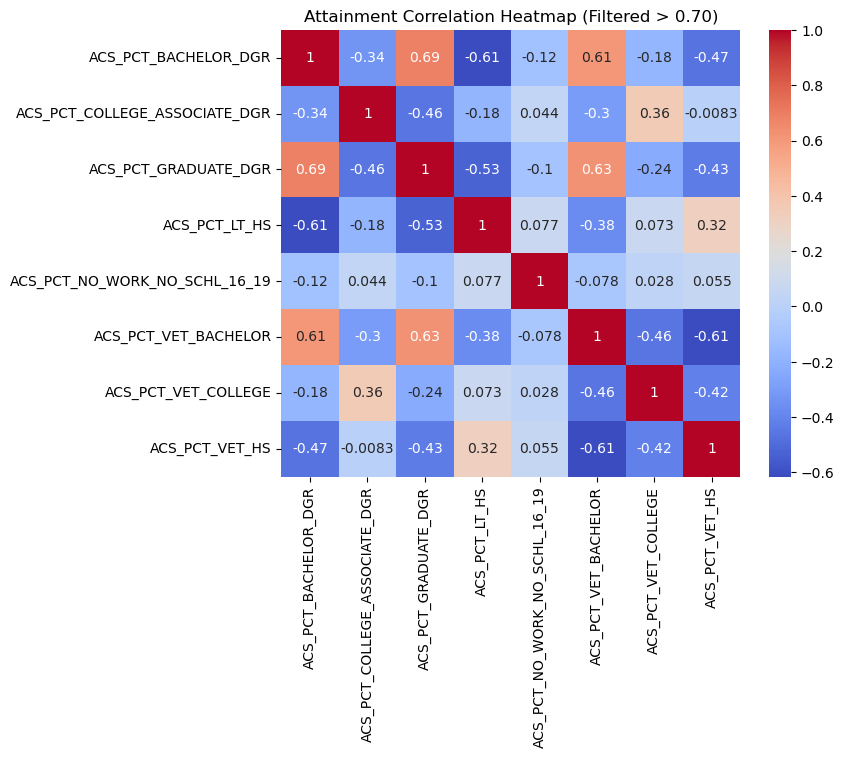

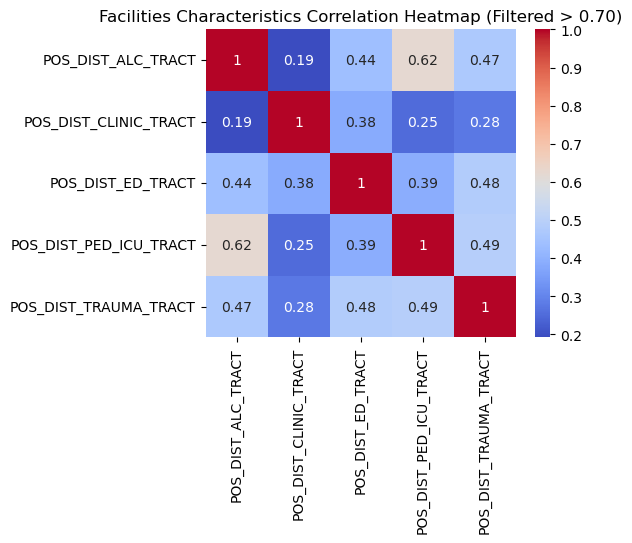

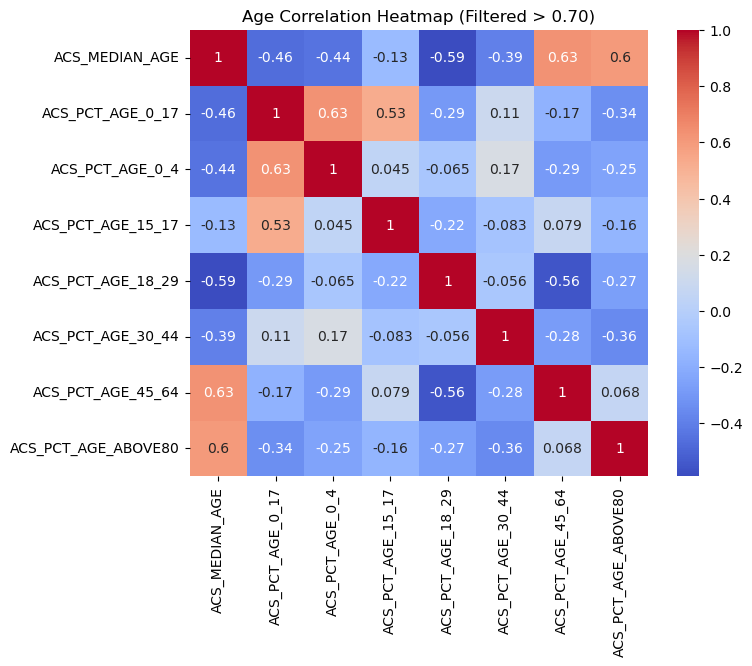

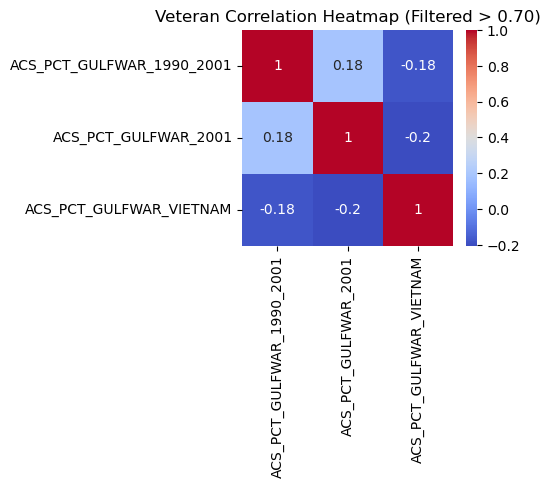

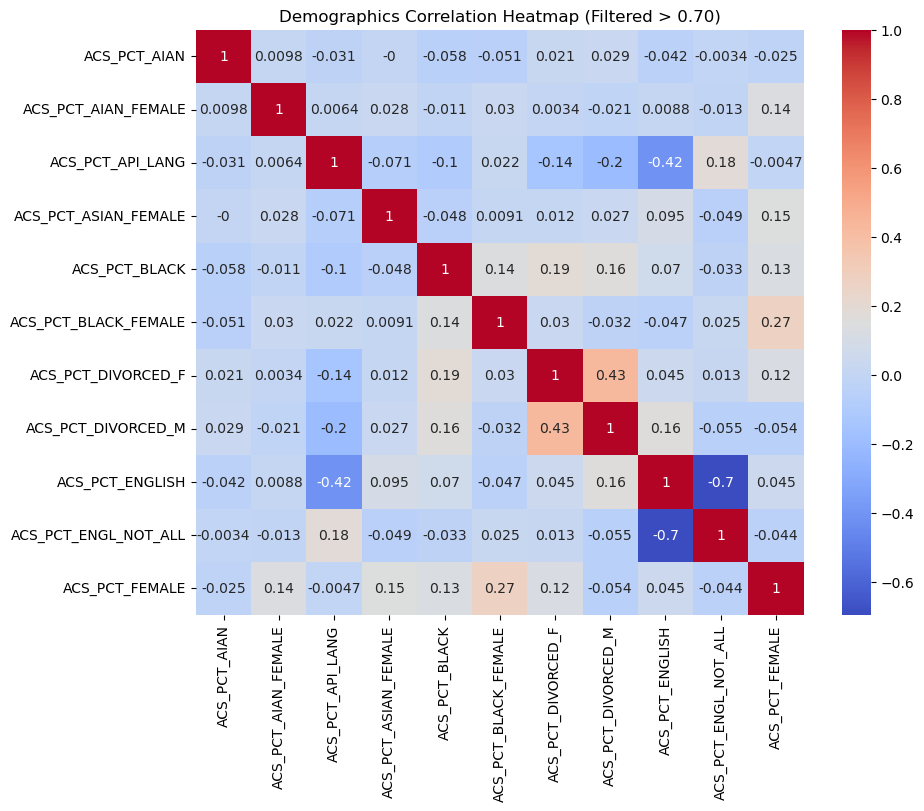

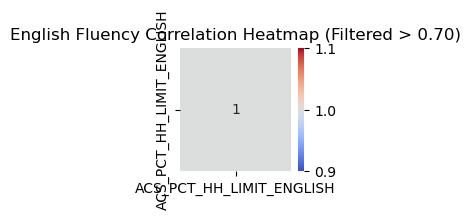

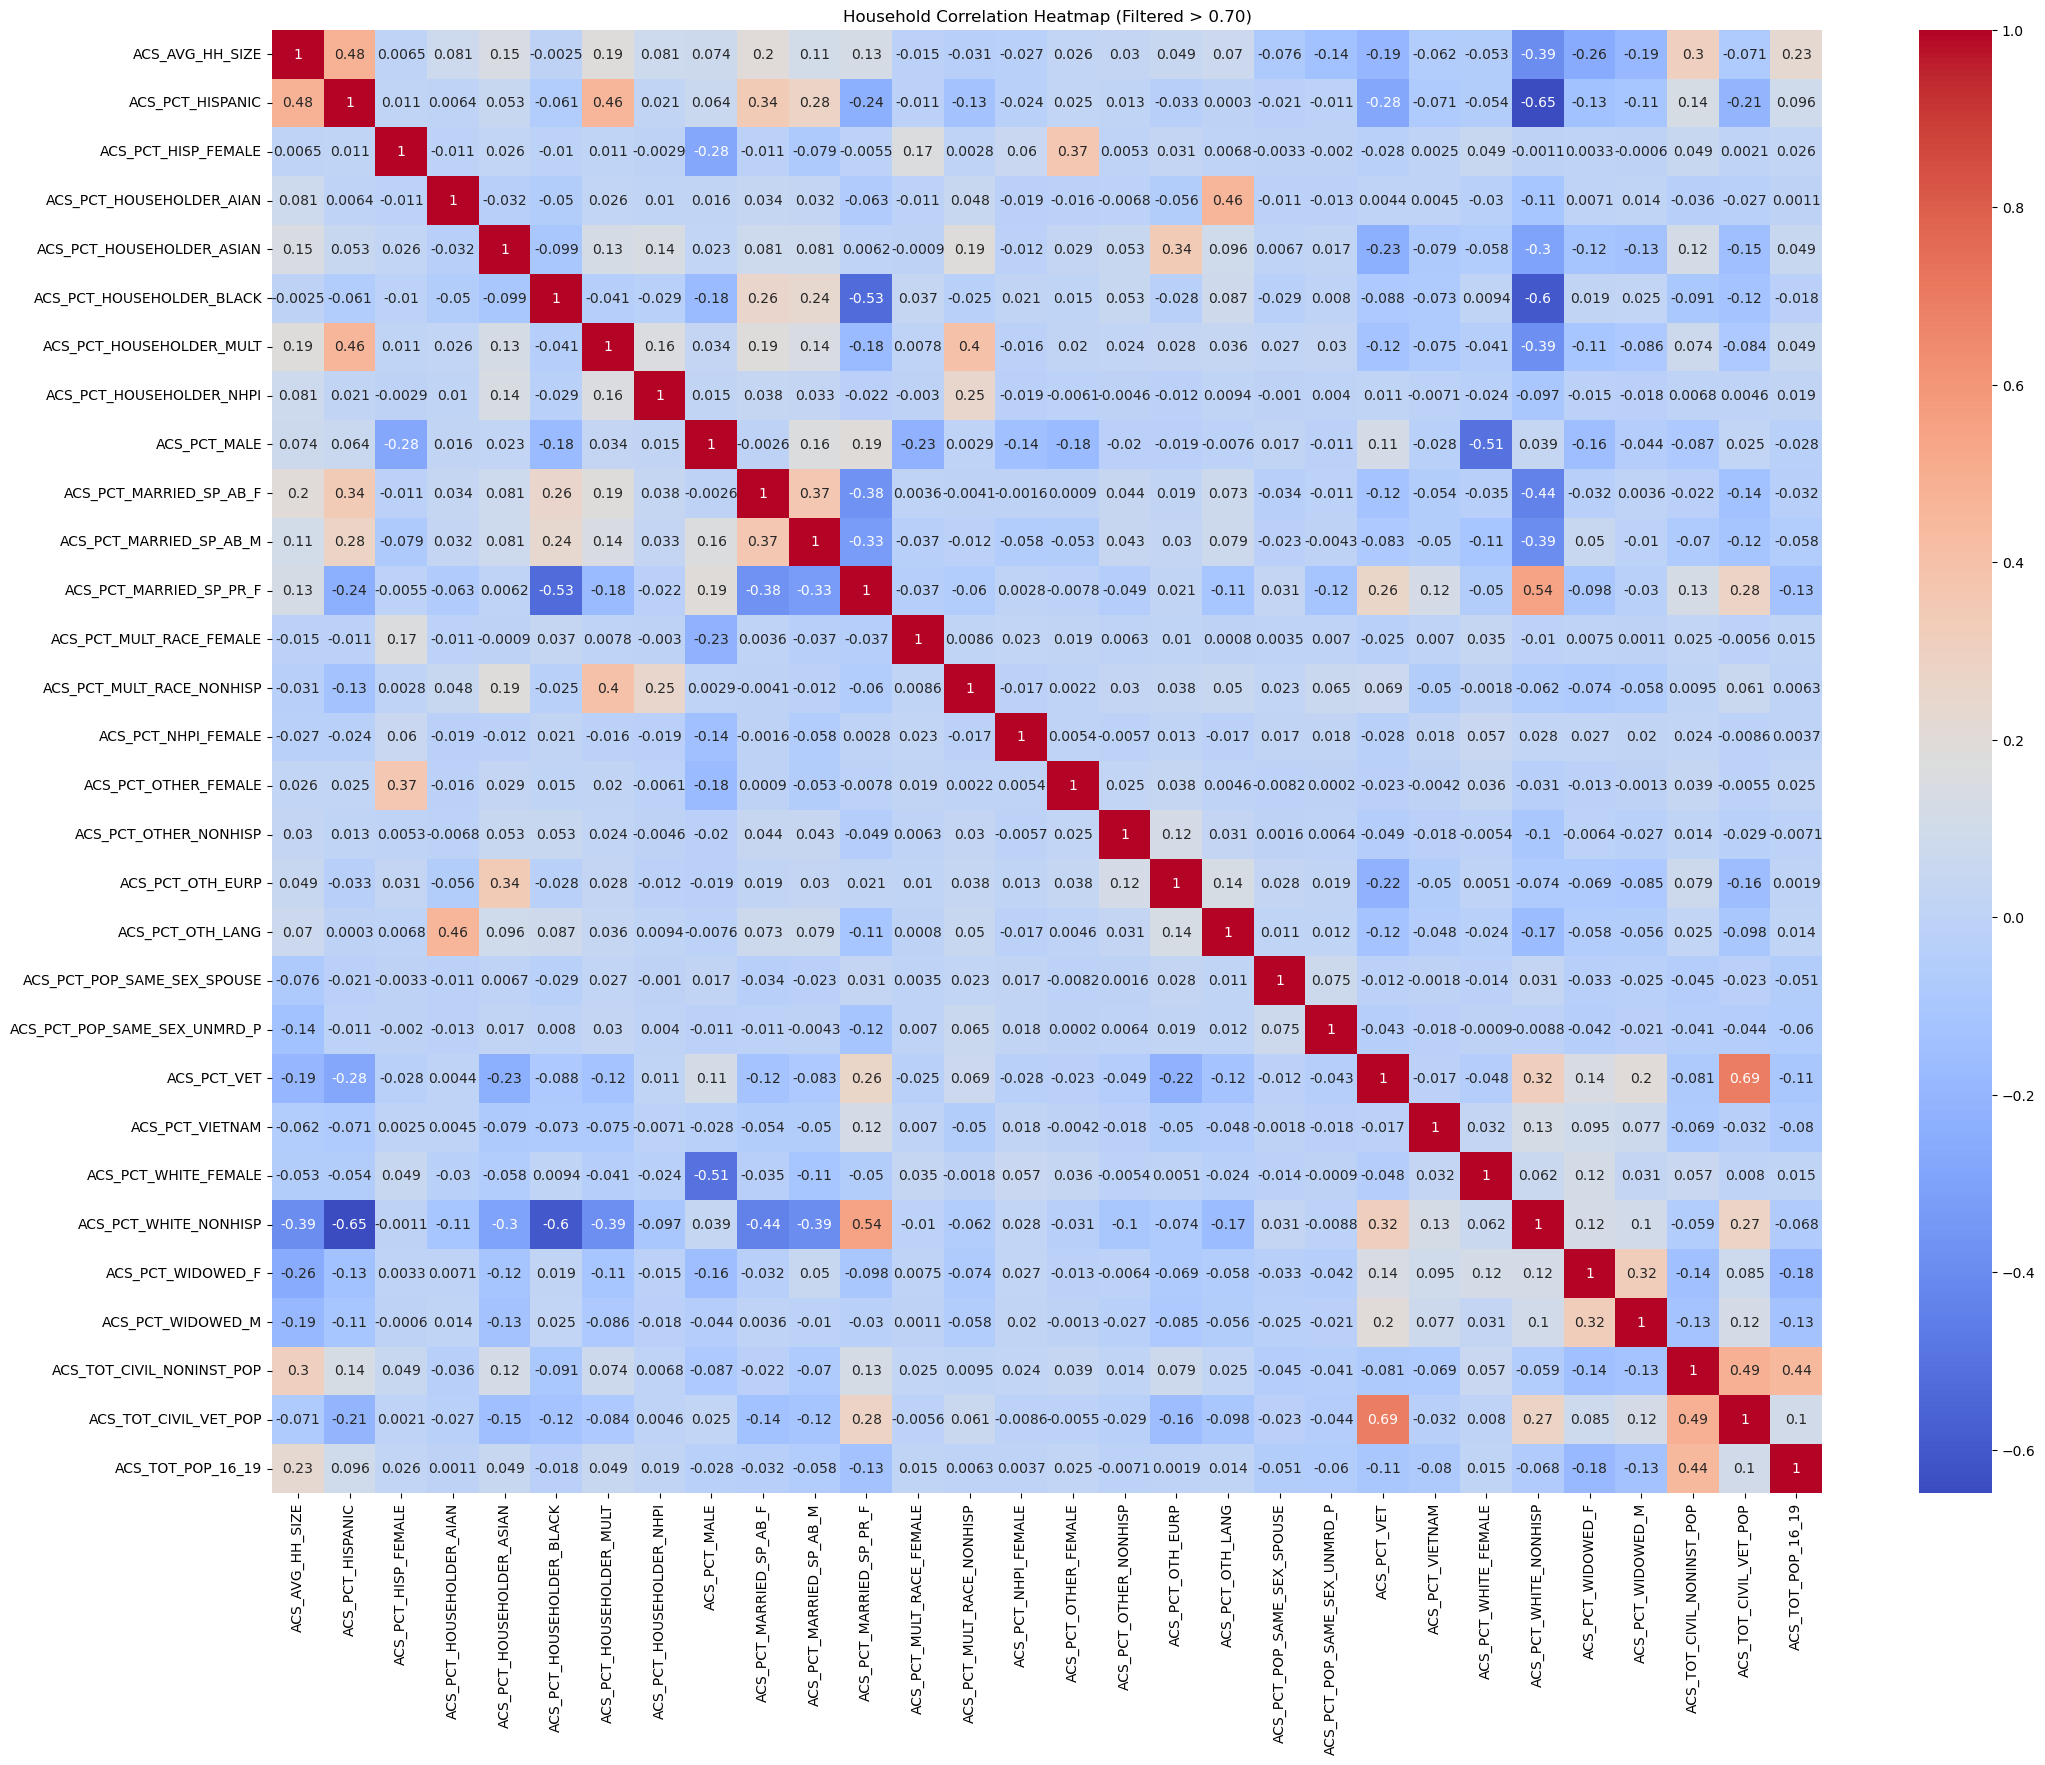

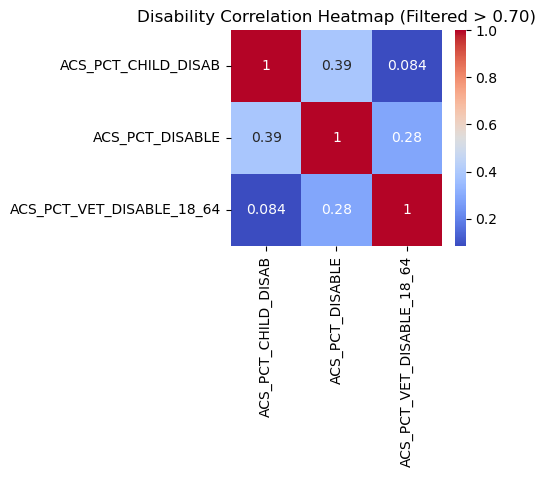

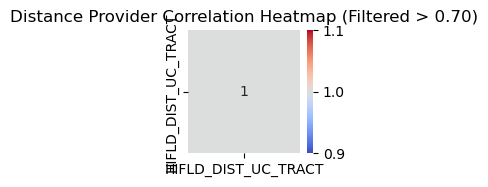

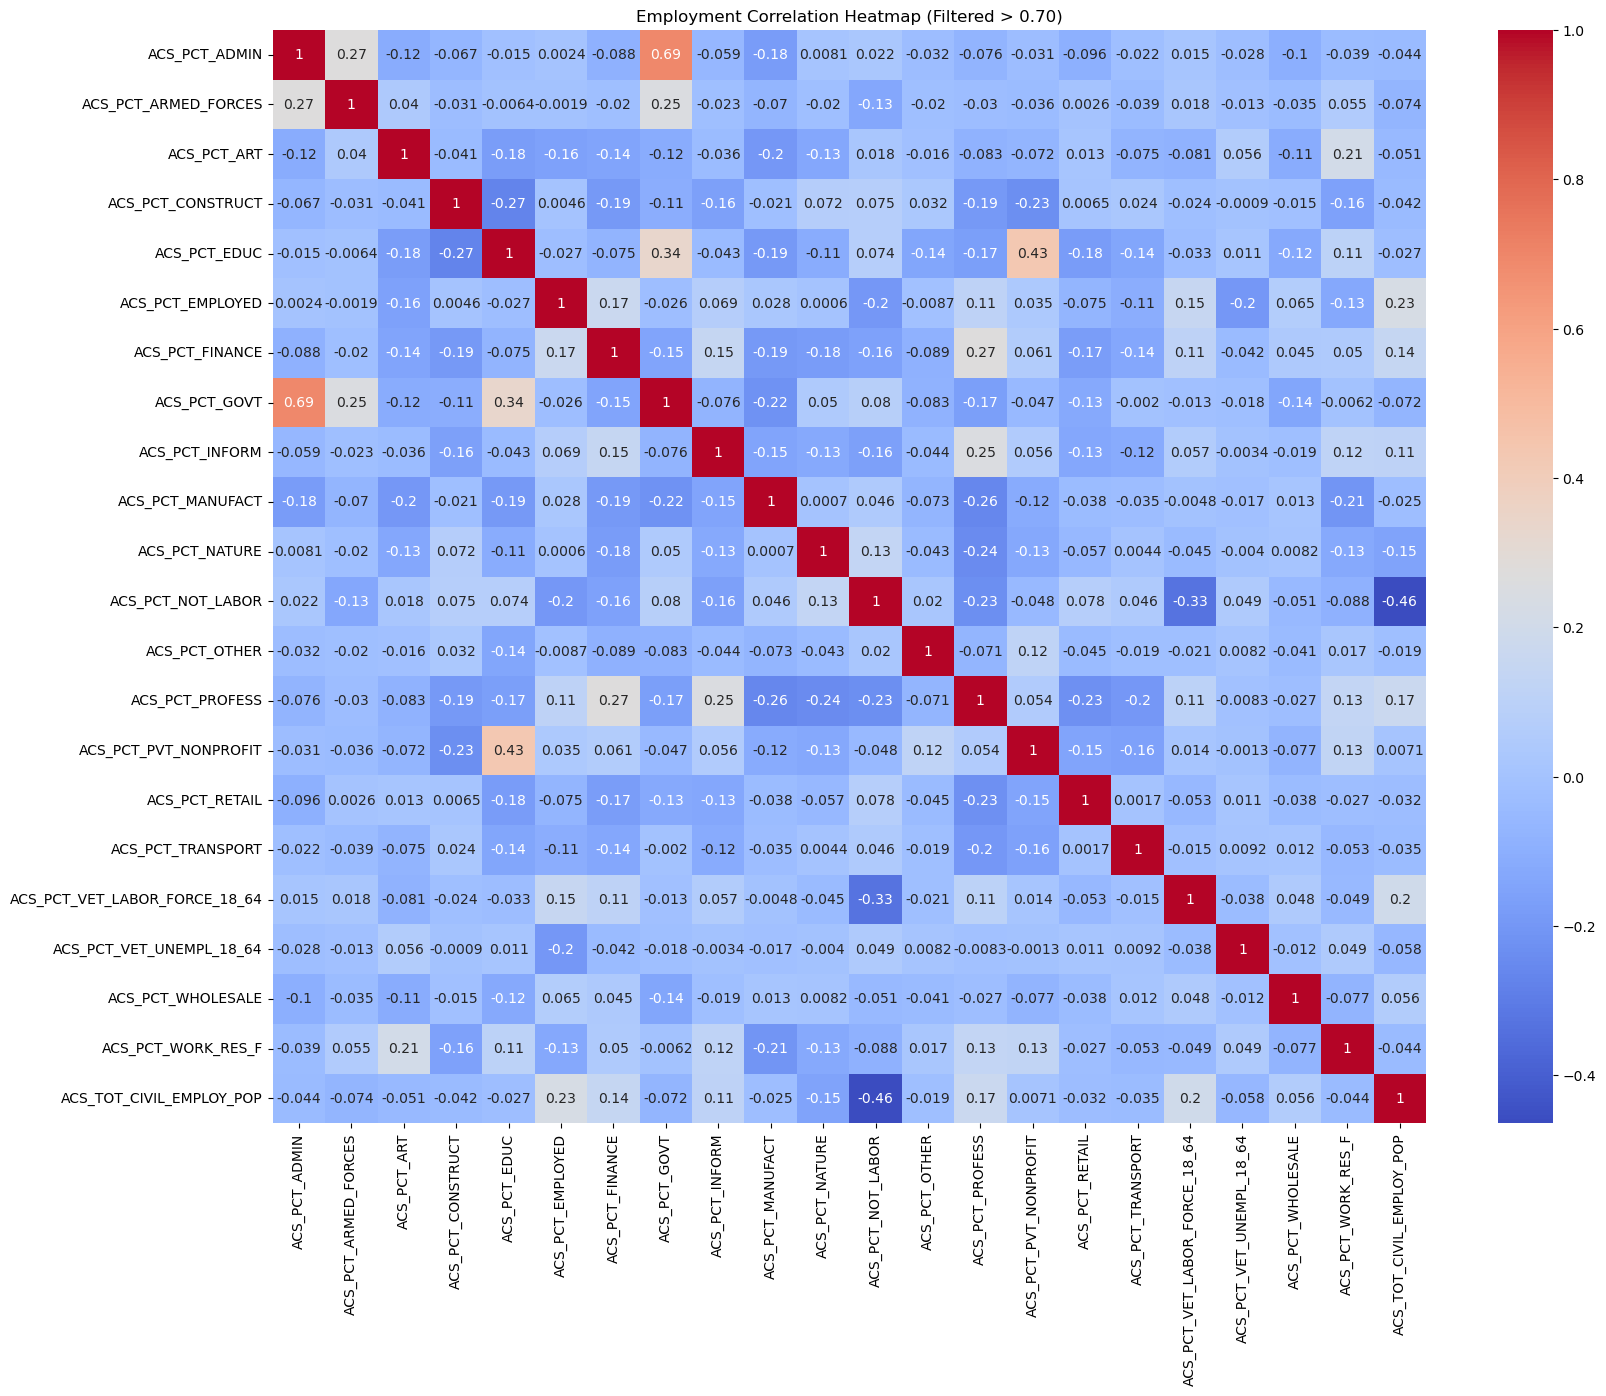

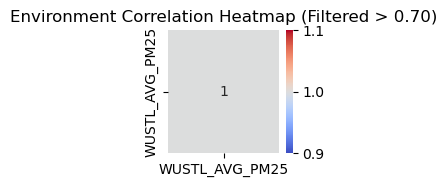

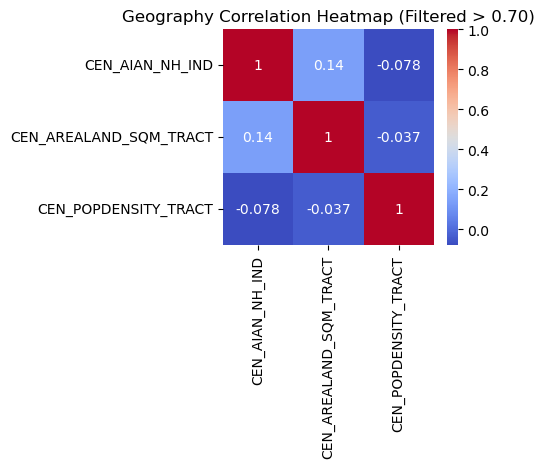

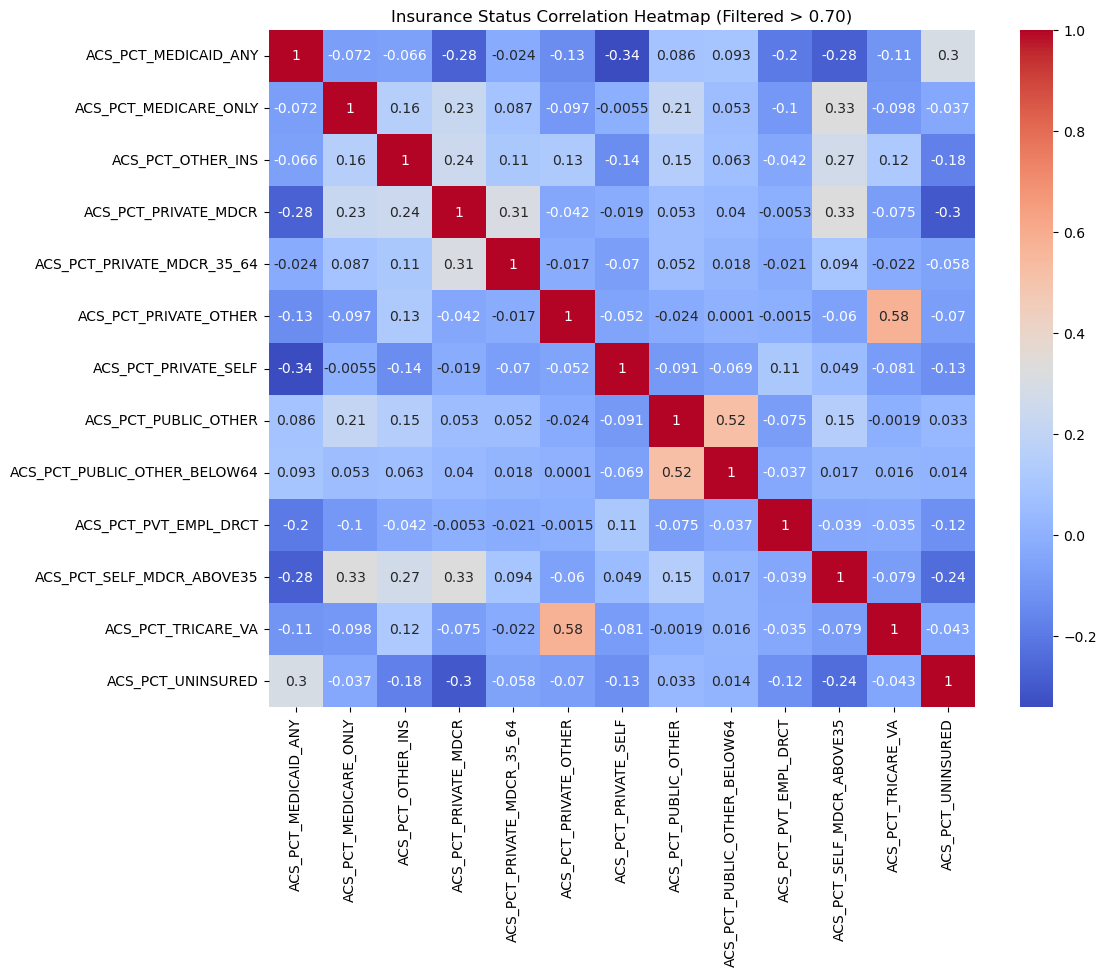

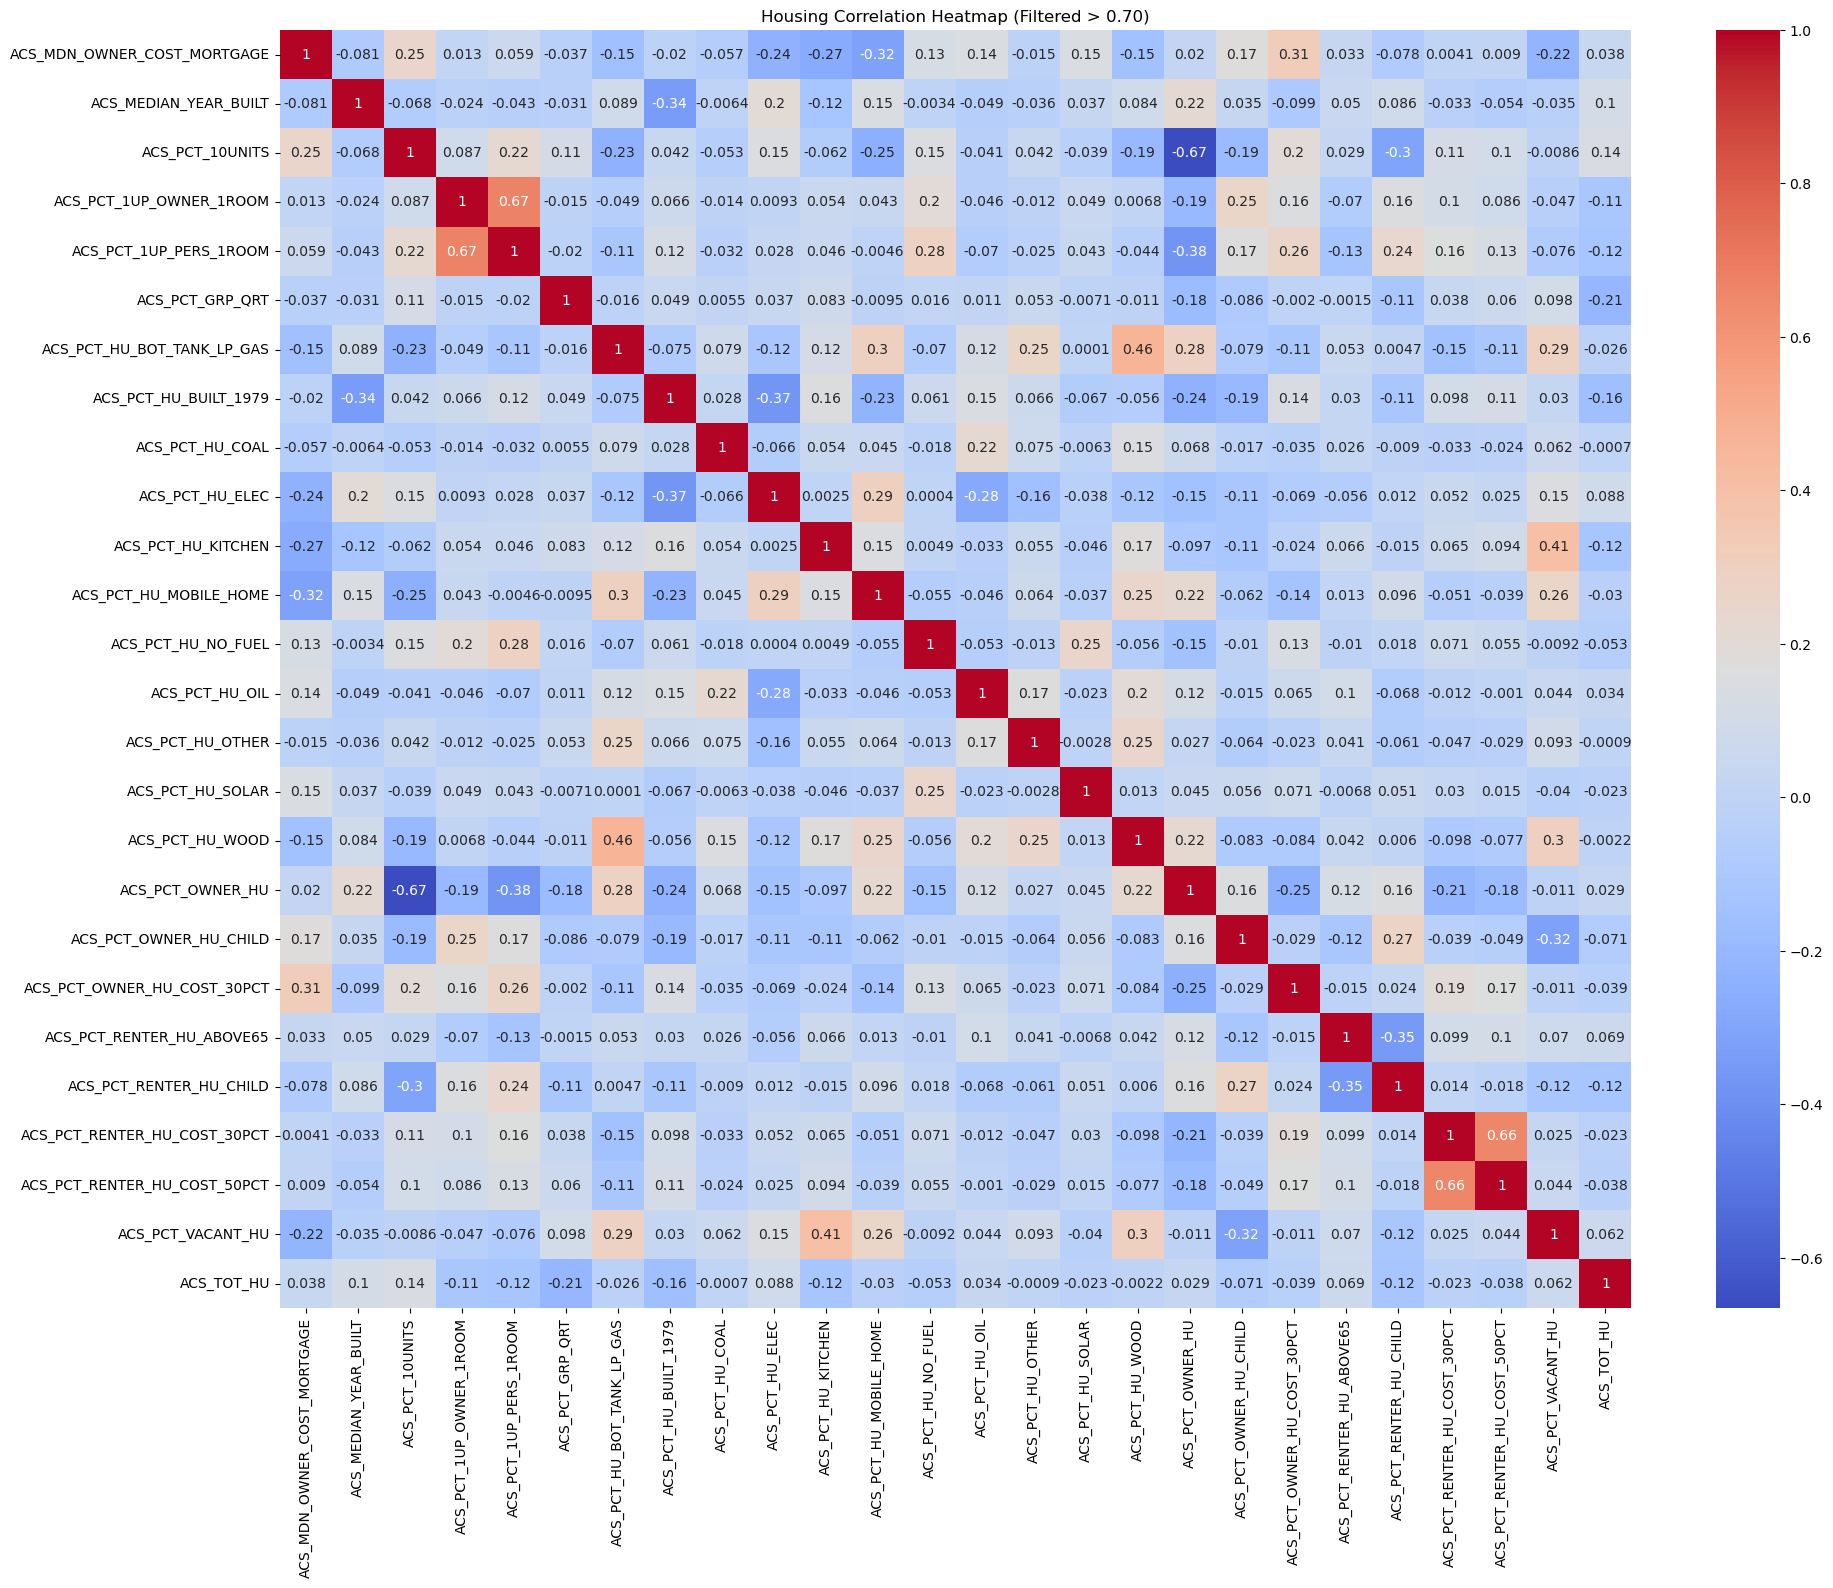

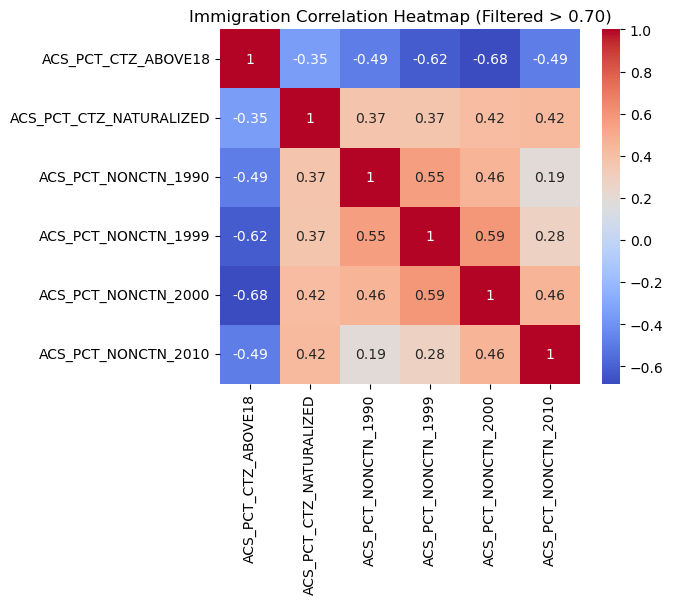

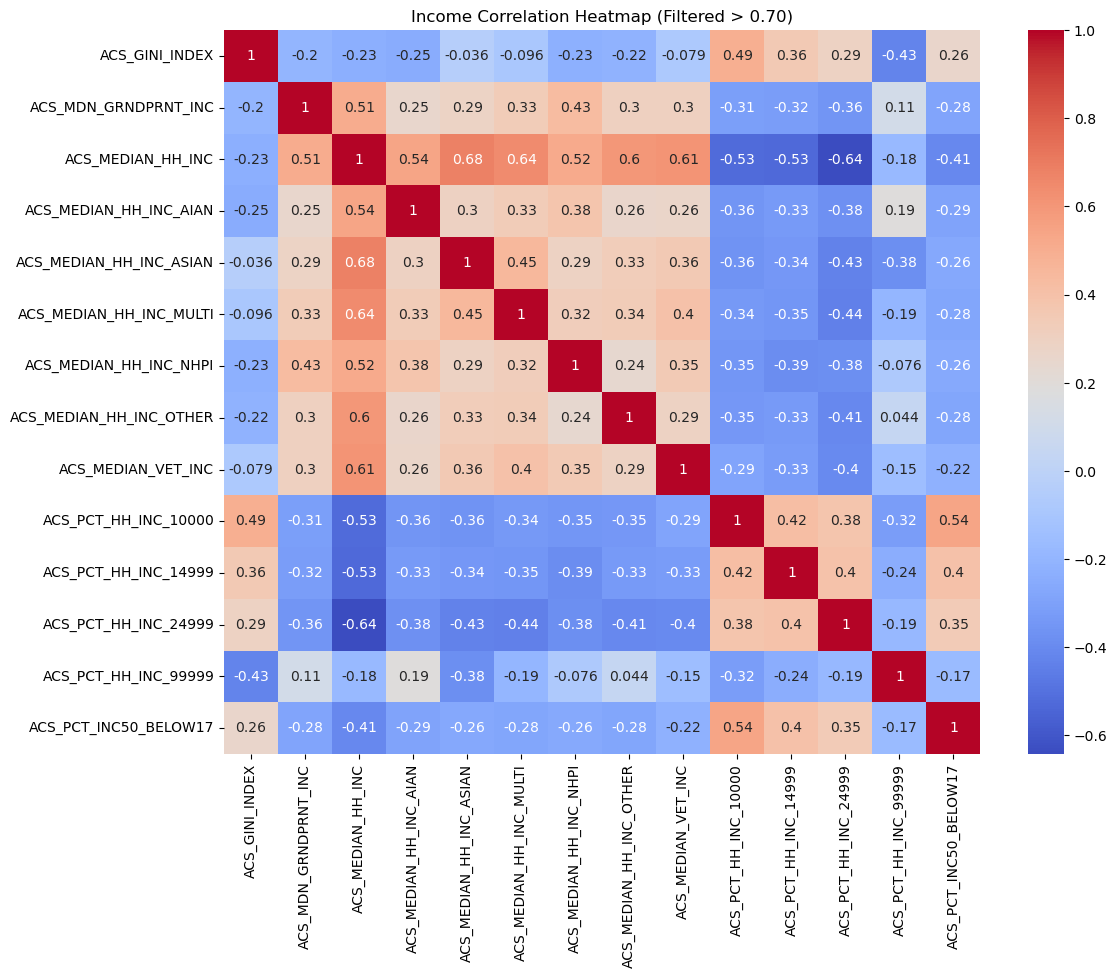

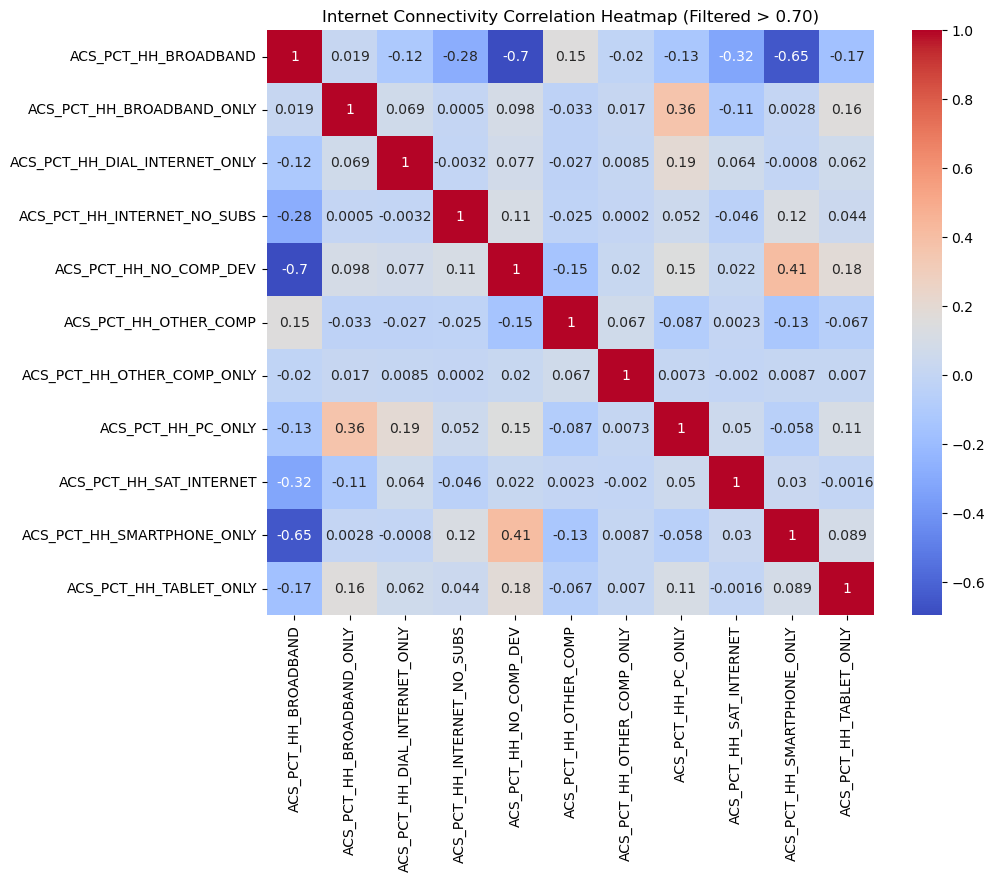

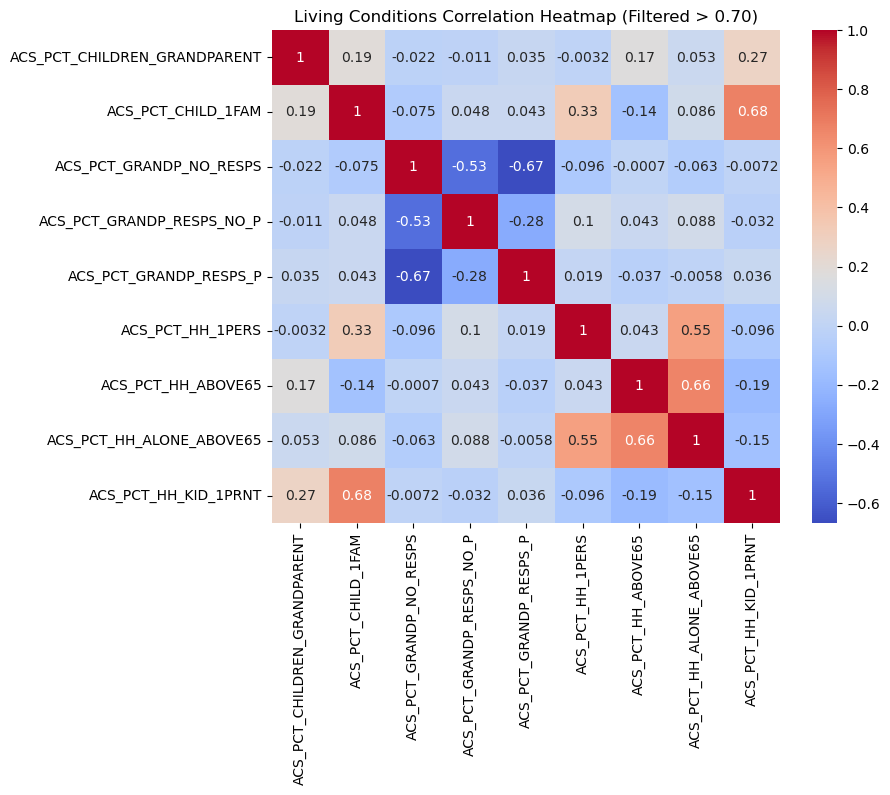

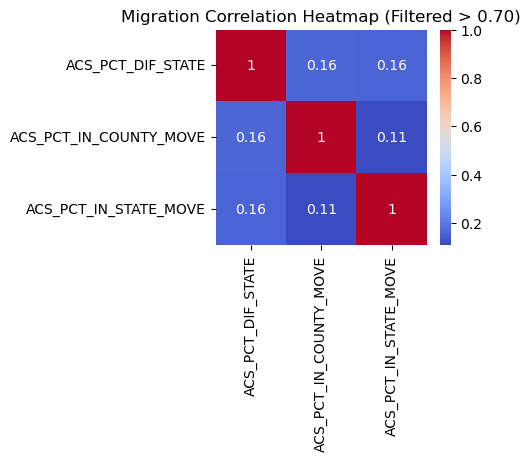

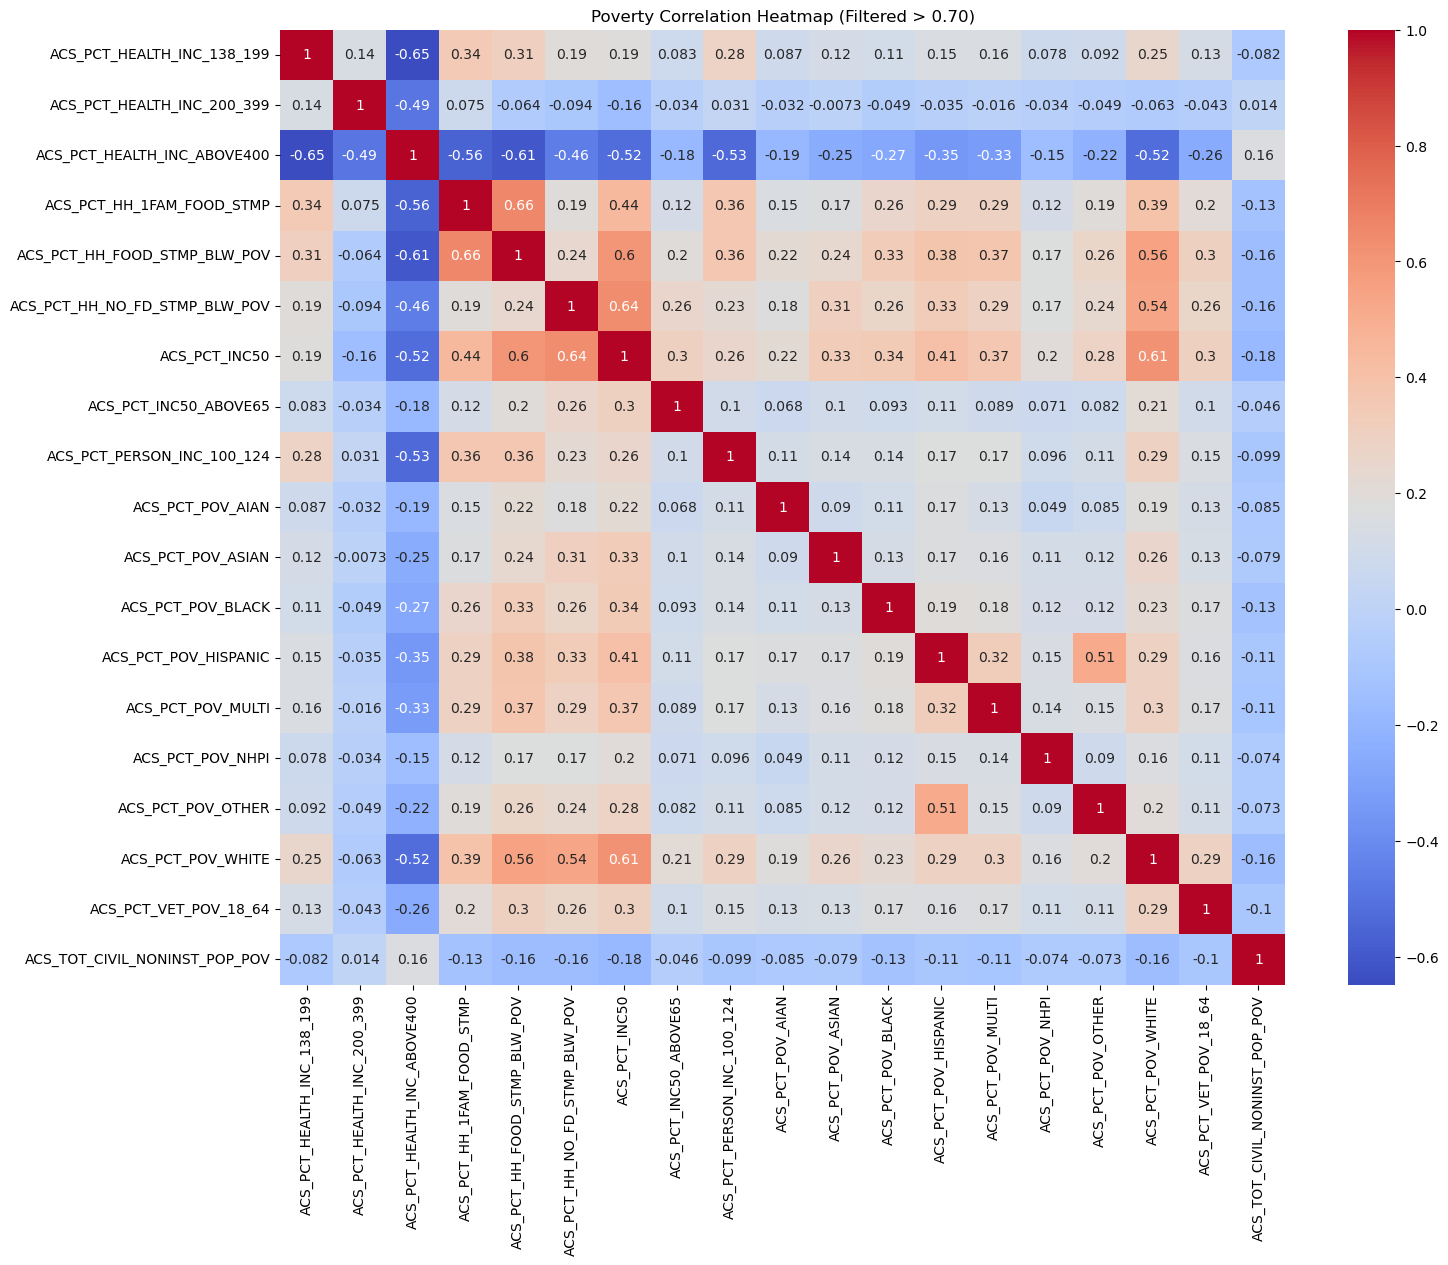

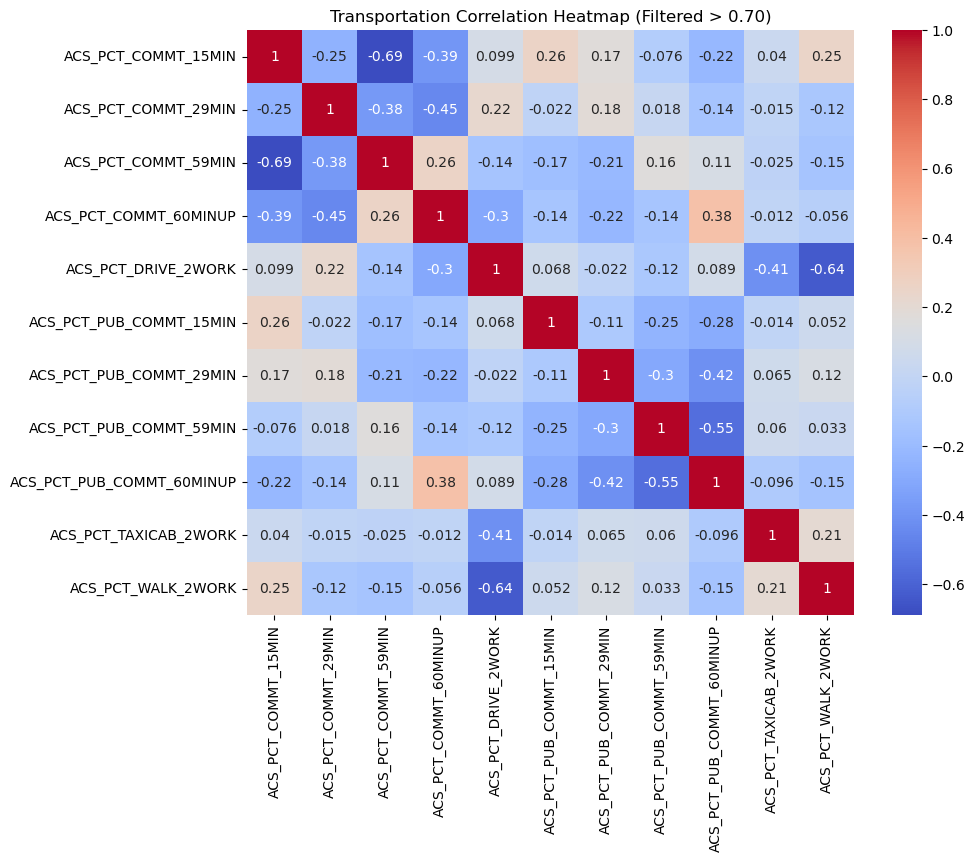

Attainment: ['ACS_PCT_BACHELOR_DGR', 'ACS_PCT_COLLEGE_ASSOCIATE_DGR', 'ACS_PCT_GRADUATE_DGR', 'ACS_PCT_LT_HS', 'ACS_PCT_NO_WORK_NO_SCHL_16_19', 'ACS_PCT_VET_BACHELOR', 'ACS_PCT_VET_COLLEGE', 'ACS_PCT_VET_HS']
Facilities Characteristics: ['POS_DIST_ALC_TRACT', 'POS_DIST_CLINIC_TRACT', 'POS_DIST_ED_TRACT', 'POS_DIST_PED_ICU_TRACT', 'POS_DIST_TRAUMA_TRACT']
Age: ['ACS_MEDIAN_AGE', 'ACS_PCT_AGE_0_17', 'ACS_PCT_AGE_0_4', 'ACS_PCT_AGE_15_17', 'ACS_PCT_AGE_18_29', 'ACS_PCT_AGE_30_44', 'ACS_PCT_AGE_45_64', 'ACS_PCT_AGE_ABOVE80']
Veteran: ['ACS_PCT_GULFWAR_1990_2001', 'ACS_PCT_GULFWAR_2001', 'ACS_PCT_GULFWAR_VIETNAM']
Demographics: ['ACS_PCT_AIAN', 'ACS_PCT_AIAN_FEMALE', 'ACS_PCT_API_LANG', 'ACS_PCT_ASIAN_FEMALE', 'ACS_PCT_BLACK', 'ACS_PCT_BLACK_FEMALE', 'ACS_PCT_DIVORCED_F', 'ACS_PCT_DIVORCED_M', 'ACS_PCT_ENGLISH', 'ACS_PCT_ENGL_NOT_ALL', 'ACS_PCT_FEMALE']
English Fluency: ['ACS_PCT_HH_LIMIT_ENGLISH']
Household: ['ACS_AVG_HH_SIZE', 'ACS_PCT_HISPANIC', 'ACS_PCT_HISP_FEMALE', 'ACS_PCT_HOUSEHOLDE

In [28]:
kept_columns_by_topic = {}   # store kept columns for each topic

for topic, columns in topics.items():

    # Load columns as pandas df
    temp = sdoh.select(columns).toPandas()
    
    # Compute correlation matrix
    corr_matrix = temp.corr().round(4)

    # ---- DROP HIGHLY CORRELATED COLUMNS (> 0.70) ----
    threshold = 0.70
    cols = list(corr_matrix.columns)
    keep = []     # final columns we keep
    drop = set()  # internal tracking of dropped ones

    for col in cols:
        if col in drop:
            continue

        # Check correlation with EACH column already in keep
        to_drop = False
        for kept_col in keep:
            if abs(corr_matrix.loc[col, kept_col]) > threshold:
                to_drop = True
                drop.add(col)
                break

        if not to_drop:
            keep.append(col)

    kept_columns_by_topic[topic] = keep

    # ---- CREATE HEATMAP WITH ONLY KEPT COLUMNS ----
    filtered_corr = corr_matrix.loc[keep, keep]

    num_columns = filtered_corr.shape[1]
    fig_width = 1 + num_columns * 0.8
    fig_height = 1 + num_columns * 0.6

    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(filtered_corr, annot=True, cmap='coolwarm')
    plt.title(f"{topic} Correlation Heatmap (Filtered > 0.70)")
    plt.show()

# Print final kept column sets
for topic, kept in kept_columns_by_topic.items():
    print(f"{topic}: {kept}")

In [29]:
cols_to_keep = ['YEAR',
    'COUNTYFIPS',
    'STATEFIPS',
    'STATE',
    'COUNTY',
    'REGION',
    'TERRITORY', 
    'ACS_PCT_BACHELOR_DGR', 'ACS_PCT_COLLEGE_ASSOCIATE_DGR', 'ACS_PCT_GRADUATE_DGR', 'ACS_PCT_HS_GRADUATE', 'ACS_PCT_LT_HS',
    'ACS_PCT_NO_WORK_NO_SCHL_16_19', 'ACS_PCT_POSTHS_ED', 'ACS_PCT_VET_BACHELOR', 'ACS_PCT_VET_COLLEGE', 'ACS_PCT_VET_HS', 
    'ACS_PCT_HH_LIMIT_ENGLISH' ,'ACS_PCT_HH_BROADBAND', 'ACS_PCT_HH_BROADBAND_ANY', 'ACS_PCT_HH_BROADBAND_ONLY',
    'ACS_PCT_HH_CELLULAR', 'ACS_PCT_HH_CELLULAR_ONLY', 'ACS_PCT_HH_DIAL_INTERNET_ONLY', 'ACS_PCT_HH_INTERNET', 
    'ACS_PCT_HH_INTERNET_NO_SUBS', 'ACS_PCT_HH_NO_COMP_DEV', 'ACS_PCT_HH_NO_INTERNET','ACS_PCT_HH_OTHER_COMP', 'ACS_PCT_HH_OTHER_COMP_ONLY',
    'ACS_PCT_HH_PC', 'ACS_PCT_HH_PC_ONLY', 'ACS_PCT_HH_SAT_INTERNET', 'ACS_PCT_HH_SMARTPHONE', 'ACS_PCT_HH_SMARTPHONE_ONLY', 'ACS_PCT_HH_TABLET', 
    'ACS_PCT_HH_TABLET_ONLY', 'ACS_PCT_CHILDREN_GRANDPARENT', 'ACS_PCT_CHILD_1FAM', 'ACS_PCT_GRANDP_NO_RESPS', 'ACS_PCT_GRANDP_RESPS_NO_P', 'ACS_PCT_GRANDP_RESPS_P', 
    'ACS_PCT_HH_1PERS', 'ACS_PCT_HH_ABOVE65', 'ACS_PCT_HH_ALONE_ABOVE65', 'ACS_PCT_HH_KID_1PRNT', 'ACS_TOT_GRANDCHILDREN_GP', 'ACS_PCT_HEALTH_INC_138_199', 
    'ACS_PCT_HEALTH_INC_200_399', 'ACS_PCT_HEALTH_INC_ABOVE400', 'ACS_PCT_HEALTH_INC_BELOW137', 'ACS_PCT_HH_1FAM_FOOD_STMP',
    'ACS_PCT_HH_FOOD_STMP', 'ACS_PCT_HH_FOOD_STMP_BLW_POV', 'ACS_PCT_HH_NO_FD_STMP_BLW_POV', 'ACS_PCT_HH_PUB_ASSIST', 'ACS_PCT_INC50', 'ACS_PCT_INC50_ABOVE65', 
    'ACS_PCT_NONVET_POV_18_64', 'ACS_PCT_PERSON_INC_100_124', 'ACS_PCT_PERSON_INC_125_199', 'ACS_PCT_PERSON_INC_ABOVE200', 'ACS_PCT_PERSON_INC_BELOW99', 
    'ACS_PCT_POV_AIAN', 'ACS_PCT_POV_ASIAN', 'ACS_PCT_POV_BLACK', 'ACS_PCT_POV_HISPANIC', 'ACS_PCT_POV_MULTI', 'ACS_PCT_POV_NHPI', 'ACS_PCT_POV_OTHER', 
    'ACS_PCT_POV_WHITE', 'ACS_PCT_VET_POV_18_64', 'ACS_TOT_CIVIL_NONINST_POP_POV', 'ACS_TOT_CIVIL_POP_POV', 'ACS_TOT_POP_POV']

df_copy = sdoh[cols_to_keep].toPandas()
df_copy = df_copy.drop_duplicates().fillna(0)
df_copy['COUNTY'] = df_copy['COUNTY'].str.replace(' County', '', regex=True)
df_grouped = df_copy.groupby(["YEAR", "COUNTYFIPS", "STATEFIPS", 
                              "STATE", "COUNTY", "REGION", "TERRITORY"], as_index=False).mean()
print(df_grouped['STATE'].unique())

['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island' 'South Carolina'
 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Vermont' 'Virginia'
 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming' 'American Samoa'
 'Guam' 'Northern Mariana Islands' 'Puerto Rico' 'US Virgin Islands']


In [30]:
df_grouped = df_grouped.drop(['YEAR', 'STATEFIPS', 'REGION', 'TERRITORY'], axis=1)
df_grouped

,COUNTYFIPS,STATE,COUNTY,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ANY,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_CIVIL_NONINST_POP_POV,ACS_TOT_CIVIL_POP_POV,ACS_TOT_POP_POV
0,1001,Alabama,Autauga,16.481765,29.157059,11.325882,32.041176,10.992941,0.760000,56.965294,40.092941,32.960588,26.944706,0.357059,62.596471,82.264706,9.120588,71.106471,13.044118,0.082353,82.346471,1.912353,8.678824,15.741176,1.107647,0.000000,73.655882,5.846471,8.088824,81.532353,9.993529,59.944118,1.157647,8.645294,27.372353,26.370000,17.681176,26.537647,26.041765,28.675294,11.450000,17.975294,60.058824,10.260000,32.495294,35.837647,21.406471,28.110000,11.575294,6.487059,7.647647,11.971176,6.041765,2.857059,14.922353,4.328235,12.265294,68.562941,14.844706,4.228235,8.288824,22.819412,16.662941,21.356471,0.000000,13.312941,11.490588,5.084118,3204.235294,2435.882353,3245.941176
1,1003,Alabama,Baldwin,20.232500,30.806364,10.956591,26.686591,9.045455,0.654091,61.995455,33.370909,33.935682,30.420909,0.616364,60.650227,82.791591,5.745000,75.658864,16.953409,0.392727,83.184545,2.739545,8.231364,11.803409,1.796136,0.000000,75.450227,4.148864,10.295000,82.471591,8.338409,61.589318,0.615909,12.223636,20.335909,38.261818,26.988636,21.113409,29.214545,36.486591,12.709545,11.428182,126.409091,11.215909,31.217500,40.283182,15.011364,20.666591,6.655455,3.178182,7.849091,7.118636,3.528864,1.740000,10.020909,4.178636,12.726818,71.512727,9.309091,11.669318,5.380682,14.856818,18.265000,7.540227,0.000000,9.378409,7.862045,5.180909,4882.931818,3827.431818,4890.227273
2,1005,Alabama,Barbour,7.906667,28.104444,4.911111,34.828889,24.248889,0.000000,40.925556,18.168889,32.200000,49.631111,1.941111,38.884444,64.524444,5.442222,57.760000,19.088889,0.416667,64.943333,5.484444,20.191111,29.571111,2.250000,0.000000,52.717778,5.017778,10.071111,69.567778,18.586667,44.781111,2.527778,22.256667,47.722222,37.283333,34.083333,28.631111,32.562222,37.374444,15.435556,26.623333,119.000000,11.927778,27.537778,22.471111,38.065556,42.835556,24.041111,17.607778,9.390000,24.041111,13.651111,3.464444,25.828889,5.608889,15.780000,50.005556,28.601111,0.000000,0.000000,38.520000,47.577778,43.222222,11.111111,27.165556,13.385556,14.931111,2452.222222,1877.111111,2452.222222
3,1007,Alabama,Bibb,7.088750,25.833750,3.910000,45.335000,17.832500,2.373750,36.832500,15.431250,18.906250,65.666250,0.463750,36.061250,74.781250,4.657500,68.220000,25.093750,0.041250,74.821250,3.398750,17.855000,21.780000,0.282500,0.000000,55.292500,4.193750,16.993750,73.360000,19.510000,47.828750,0.815000,23.251250,31.780000,48.618750,20.171250,18.710000,24.96875

In [31]:
acs_cols = [c for c in df_grouped.columns if c.startswith("ACS_")]

# Keep only rows where NOT all ACS_* are zero
df_clean = df_grouped[~(df_grouped[acs_cols].eq(0.0).all(axis=1))]
df_clean

,COUNTYFIPS,STATE,COUNTY,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ANY,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_CIVIL_NONINST_POP_POV,ACS_TOT_CIVIL_POP_POV,ACS_TOT_POP_POV
0,1001,Alabama,Autauga,16.481765,29.157059,11.325882,32.041176,10.992941,0.760000,56.965294,40.092941,32.960588,26.944706,0.357059,62.596471,82.264706,9.120588,71.106471,13.044118,0.082353,82.346471,1.912353,8.678824,15.741176,1.107647,0.000000,73.655882,5.846471,8.088824,81.532353,9.993529,59.944118,1.157647,8.645294,27.372353,26.370000,17.681176,26.537647,26.041765,28.675294,11.450000,17.975294,60.058824,10.260000,32.495294,35.837647,21.406471,28.110000,11.575294,6.487059,7.647647,11.971176,6.041765,2.857059,14.922353,4.328235,12.265294,68.562941,14.844706,4.228235,8.288824,22.819412,16.662941,21.356471,0.000000,13.312941,11.490588,5.084118,3204.235294,2435.882353,3245.941176
1,1003,Alabama,Baldwin,20.232500,30.806364,10.956591,26.686591,9.045455,0.654091,61.995455,33.370909,33.935682,30.420909,0.616364,60.650227,82.791591,5.745000,75.658864,16.953409,0.392727,83.184545,2.739545,8.231364,11.803409,1.796136,0.000000,75.450227,4.148864,10.295000,82.471591,8.338409,61.589318,0.615909,12.223636,20.335909,38.261818,26.988636,21.113409,29.214545,36.486591,12.709545,11.428182,126.409091,11.215909,31.217500,40.283182,15.011364,20.666591,6.655455,3.178182,7.849091,7.118636,3.528864,1.740000,10.020909,4.178636,12.726818,71.512727,9.309091,11.669318,5.380682,14.856818,18.265000,7.540227,0.000000,9.378409,7.862045,5.180909,4882.931818,3827.431818,4890.227273
2,1005,Alabama,Barbour,7.906667,28.104444,4.911111,34.828889,24.248889,0.000000,40.925556,18.168889,32.200000,49.631111,1.941111,38.884444,64.524444,5.442222,57.760000,19.088889,0.416667,64.943333,5.484444,20.191111,29.571111,2.250000,0.000000,52.717778,5.017778,10.071111,69.567778,18.586667,44.781111,2.527778,22.256667,47.722222,37.283333,34.083333,28.631111,32.562222,37.374444,15.435556,26.623333,119.000000,11.927778,27.537778,22.471111,38.065556,42.835556,24.041111,17.607778,9.390000,24.041111,13.651111,3.464444,25.828889,5.608889,15.780000,50.005556,28.601111,0.000000,0.000000,38.520000,47.577778,43.222222,11.111111,27.165556,13.385556,14.931111,2452.222222,1877.111111,2452.222222
3,1007,Alabama,Bibb,7.088750,25.833750,3.910000,45.335000,17.832500,2.373750,36.832500,15.431250,18.906250,65.666250,0.463750,36.061250,74.781250,4.657500,68.220000,25.093750,0.041250,74.821250,3.398750,17.855000,21.780000,0.282500,0.000000,55.292500,4.193750,16.993750,73.360000,19.510000,47.828750,0.815000,23.251250,31.780000,48.618750,20.171250,18.710000,24.96875

# US Zip Codes
https://simplemaps.com/data/us-zips

In [32]:
zips = pd.read_csv('data/uszips.csv',low_memory=False)
zips = zips[['zip','city', 'state_id', 'state_name', 'county_name']]
print(zips.columns)
print(zips.shape)
print(zips.dtypes)
zips


Index(['zip', 'city', 'state_id', 'state_name', 'county_name'], dtype='object')
(33782, 5)
zip             int64
city           object
state_id       object
state_name     object
county_name    object
dtype: object


,zip,city,state_id,state_name,county_name
0,601,Adjuntas,PR,Puerto Rico,Adjuntas
1,602,Aguada,PR,Puerto Rico,Aguada
2,603,Aguadilla,PR,Puerto Rico,Aguadilla
3,606,Maricao,PR,Puerto Rico,Maricao
4,610,Anasco,PR,Puerto Rico,Añasco
...,...,...,...,...,...
33777,99774,Stevens Village,AK,Alaska,Yukon-Koyukuk
33778,99778,Teller,AK,Alaska,Nome
33779,99790,Fairbanks,AK,Alaska,Yukon-Koyukuk
33780,99850,Juneau,AK,Alaska,Haines


In [35]:
mask = zips['zip'].str.match(r'^\d{5}$')
zips = zips[mask]
#zips['state_id'] = zips['state_id'].astype(str).str.strip().str.upper()
zips

,zip,city,state_id,state_name,county_name
2543,10001,New York,NY,New York,New York
2544,10002,New York,NY,New York,New York
2545,10003,New York,NY,New York,New York
2546,10004,New York,NY,New York,New York
2547,10005,New York,NY,New York,New York
...,...,...,...,...,...
33777,99774,Stevens Village,AK,Alaska,Yukon-Koyukuk
33778,99778,Teller,AK,Alaska,Nome
33779,99790,Fairbanks,AK,Alaska,Yukon-Koyukuk
33780,99850,Juneau,AK,Alaska,Haines


# Census County 2020

In [36]:
census = pd.read_csv('../data/2020_UA_COUNTY.csv', low_memory=False, usecols=['STATE', 'COUNTY', 'STATE_NAME', 'COUNTY_NAME', 'POP_COU', 'HOU_COU','POP_URB', 'POPPCT_URB', 'POP_RUR', 'POPPCT_RUR']).dropna()
for col in ['POP_COU', 'HOU_COU', 'POP_URB', 'POP_RUR']:
    census[col] = census[col].astype(str).str.replace(',', '').astype(int)
census['POPPCT_URB'] = census['POPPCT_URB'].astype(str).str.replace('%', '').astype(float)
census['POPPCT_RUR'] = census['POPPCT_RUR'].astype(str).str.replace('%', '').astype(float)
census

,STATE,COUNTY,STATE_NAME,COUNTY_NAME,POP_COU,HOU_COU,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR
0,1.0,1.0,Alabama,Autauga,58805,24350,34885,59.32,23920,40.68
1,1.0,3.0,Alabama,Baldwin,231767,124148,144654,62.41,87113,37.59
2,1.0,5.0,Alabama,Barbour,25223,11618,8596,34.08,16627,65.92
3,1.0,7.0,Alabama,Bibb,22293,9002,0,0.00,22293,100.00
4,1.0,9.0,Alabama,Blount,59134,24622,5624,9.51,53510,90.49
...,...,...,...,...,...,...,...,...,...,...
3229,72.0,151.0,Puerto Rico,Yabucoa,30426,14283,24925,81.92,5501,18.08
3230,72.0,153.0,Puerto Rico,Yauco,34172,16599,28084,82.18,6088,17.82
3231,78.0,10.0,US Virgin Islands,St. Croix,41004,25470,38372,93.58,2632,6.42
3232,78.0,20.0,US Virgin Islands,St. John,3881,3645,2964,76.37,917,23.63


In [37]:
print(census.shape)
census['STATE_NAME'].unique()

(3234, 10)


array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana',
       'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
       'New Jersey', 'New Mexico', 'New York', 'North Carolina',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming', 'American Samoa', 'Guam',
       'Commonwealth of the Northern Marianas', 'Puerto Rico',
       'US Virgin Islands'], dtype=object)

In [38]:
merged_df = zips.merge(census, left_on='county_name', right_on='COUNTY_NAME', how='outer').drop('county_name', axis=1).drop(['STATE', 'STATE_NAME','COUNTY'], axis=1)
merged_df

,zip,city,state_id,state_name,COUNTY_NAME,POP_COU,HOU_COU,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR
0,29620,Abbeville,SC,South Carolina,Abbeville,24295.0,11540.0,5107.0,21.02,19188.0,78.98
1,29628,Calhoun Falls,SC,South Carolina,Abbeville,24295.0,11540.0,5107.0,21.02,19188.0,78.98
2,29638,Donalds,SC,South Carolina,Abbeville,24295.0,11540.0,5107.0,21.02,19188.0,78.98
3,29639,Due West,SC,South Carolina,Abbeville,24295.0,11540.0,5107.0,21.02,19188.0,78.98
4,29655,Iva,SC,South Carolina,Abbeville,24295.0,11540.0,5107.0,21.02,19188.0,78.98
...,...,...,...,...,...,...,...,...,...,...,...
149744,78829,Batesville,TX,Texas,Zavala,9670.0,3920.0,6709.0,69.38,2961.0,30.62
149745,78839,Crystal City,TX,Texas,Zavala,9670.0,3920.0,6709.0,69.38,2961.0,30.62
149746,78872,La Pryor,TX,Texas,Zavala,9670.0,3920.0,6709.0,69.38,2961.0,30.62
149747,57622,Cherry Creek,SD,South Dakota,Ziebach,2413.0,882.0,0.0,0.00,2413.0,100.00


In [39]:
merged_df = merged_df.dropna(subset=['COUNTY_NAME'])
print(merged_df['COUNTY_NAME'].nunique())

1931


In [40]:
df_merged = merged_df.merge(
    df_clean,
    left_on=['COUNTY_NAME'],
    right_on=['COUNTY'], how='inner'
).drop(['COUNTY', 'STATE'], axis=1)
df_merged

,zip,city,state_id,state_name,COUNTY_NAME,POP_COU,HOU_COU,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR,COUNTYFIPS,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ANY,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_CIVIL_NONINST_POP_POV,ACS_TOT_CIVIL_POP_POV,ACS_TOT_POP_POV
0,29620,Abbeville,SC,South Carolina,Abbeville,24295.0,11540.0,5107.0,21.02,19188.0,78.98,45001,13.201429,29.551429,5.385714,35.508571,16.348571,2.50,48.141429,17.4900,34.372857,48.1400,0.7300,57.044286,74.254286,10.091429,63.724286,15.927143,0.13,74.381429,4.121429,15.748571,21.495714,1.231429,0.128571,61.551429,7.3200,3.125714,72.137143,13.055714,51.261429,2.541429,9.425714,31.058571,45.437143,36.7900,17.772857,29.2100,38.372857,14.728571,16.335714,74.142857,11.044286,38.354286,25.02,25.582857,45.761429,15.427143,8.005714,10.631429,15.8300,7.292857,2.114286,16.021429,6.331429,13.271429,63.378571,17.018571,14.285714,0.0,22.351429,20.462857,42.514286,0.0,28.571429,12.747143,10.842857,3406.714286,2696.714286,3410.714286
1,29628,Calhoun Falls,SC,South Carolina,Abbeville,24295.0,11540.0,5107.0,21.02,19188.0,78.98,45001,13.201429,29.551429,5.385714,35.508571,16.348571,2.50,48.141429,17.4900,34.372857,48.1400,0.7300,57.044286,74.254286,10.091429,63.724286,15.927143,0.13,74.381429,4.121429,15.748571,21.495714,1.231429,0.128571,61.551429,7.3200,3.125714,72.137143,13.055714,51.261429,2.541429,9.425714,31.058571,45.437143,36.7900,17.772857,29.2100,38.372857,14.728571,16.335714,74.142857,11.044286,38.354286,25.02,25.582857,45.761429,15.427143,8.005714,10.631429,15.8300,7.292857,2.114286,16.021429,6.331429,13.271429,63.378571,17.018571,14.285714,0.0,22.351429,20.462857,42.514286,0.0,28.571429,12.747143,10.842857,3406.714286,2696.714286,3410.714286
2,29638,Donalds,SC,South Carolina,Abbeville,24295.0,11540.0,5107.0,21.02,19188.0,78.98,45001,13.201429,29.551429,5.385714,35.508571,16.348571,2.50,48.141429,17.4900,34.372857,48.1400,0.7300,57.044286,74.254286,10.091429,63.724286,15.927143,0.13,74.381429,4.121429,15.748571,21.495714,1.231429,0.128571,61.551429,7.3200,3.125714,72.137143,13.055714,51.261429,2.541429,9.425714,31.058571,45.437143,36.7900,17.772857,29.2100,38.372857,14.728571,16.335714,74.142857,11.044286,38.354286,25.02,25.582857,45.761429,15.427143,8.005714,10.631429,15.8300,7.292857,2.114286,16.021429,6.331429,13.271429,63.378571,17.018571,14.285714,0.0,22.351429,20.462857,42.514286,0.0,28.571429,12.747143,10.842857,3406.714286,2696.714286,3410.714286
3,29639,Due West,SC,South Carolina,Abbeville,24295.0,11540.0,5107.0,21.02,19188.0,78.98,45001,13.201429,29.551429,5.385714,35.508571,16.348571,2.50,48.141429,17.490

In [41]:
corr_drops = [
    'POP_COU',    # Keep POP_URB 
    'HOU_COU',    # Redundant with POP_URB
    'ACS_TOT_CIVIL_NONINST_POP_POV',  # Keep ACS_TOT_POP_POV
    'ACS_TOT_CIVIL_POP_POV',          # Keep ACS_TOT_POP_POV
    'ACS_PCT_HH_BROADBAND_ANY',       # Keep ACS_PCT_HH_INTERNET
    'ACS_PCT_HH_FOOD_STMP',           # Keep ACS_PCT_HH_PUB_ASSIST
]
df_merged = df_merged.drop(corr_drops, axis=1)

In [45]:
df_merged = df_merged[df_merged['state_id'] == 'TX']
df_merged = df_merged.drop_duplicates()

df_merged

,zip,city,state_id,state_name,COUNTY_NAME,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR,COUNTYFIPS,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_POP_POV
16299,75763,Frankston,TX,Texas,Anderson,0.0,0.00,7836.0,100.00,20003,10.365000,29.920000,7.170000,41.025000,11.515000,4.520000,47.460000,18.080000,19.050000,62.870000,1.120000,45.850000,11.815000,55.280000,13.295000,0.890000,70.980000,7.660000,15.20000,21.360000,2.325000,0.045000,67.535000,8.980000,13.850000,68.430000,11.355000,49.130000,3.230000,10.905000,21.390000,19.710000,30.070000,50.220000,28.645000,34.770000,12.745000,16.570000,124.000000,10.255000,40.130000,27.490000,22.135000,36.395000,3.540000,10.500000,12.280000,4.540000,3.460000,13.685000,5.950000,11.595000,67.650000,14.805000,8.335000,0.000000,50.000000,66.345000,20.970000,0.000000,0.000000,13.760000,7.405000,3860.000000
16300,75763,Frankston,TX,Texas,Anderson,0.0,0.00,7836.0,100.00,21005,14.665000,32.395000,8.280000,35.245000,9.413333,0.736667,55.340000,28.996667,33.803333,37.201667,0.000000,47.370000,5.228333,72.048333,20.471667,0.191667,80.806667,2.871667,11.91500,16.320000,1.225000,0.000000,70.650000,5.053333,15.025000,79.686667,10.383333,56.385000,1.643333,14.980000,25.100000,42.020000,17.373333,40.606667,25.500000,31.763333,11.175000,15.386667,87.500000,12.373333,32.163333,34.748333,20.715000,15.461667,4.895000,7.765000,10.136667,6.245000,3.505000,16.195000,3.706667,14.238333,66.911667,15.146667,0.000000,0.000000,27.773333,21.923333,31.685000,0.000000,0.000000,13.476667,8.738333,3721.166667
16301,75763,Frankston,TX,Texas,Anderson,0.0,0.00,7836.0,100.00,45007,14.244314,31.171765,8.335882,31.285686,14.962353,3.965294,53.752353,21.048039,37.957647,40.994706,0.674314,60.758824,7.661569,70.916471,14.975490,0.088235,79.756078,3.293137,10.81098,16.950784,2.861569,0.048824,70.073137,5.143529,6.901569,80.687255,11.490784,58.552157,1.396275,11.974118,31.691373,43.855490,24.061961,24.239020,27.293922,32.953529,12.203529,18.329216,110.784314,12.969804,33.157843,30.707647,23.165098,23.877843,6.178039,7.190196,12.567647,6.091569,2.692353,13.261961,6.397451,15.753333,63.836275,14.014314,6.002745,5.698235,21.098039,19.613725,20.439216,1.960784,14.176078,11.945098,9.738431,3868.980392
16302,75763,Frankston,TX,Texas,Anderson,0.0,0.00,7836.0,100.00,47001,12.028000,29.764500,9.444500,33.084500,10.676500,1.679000,51.239500,20.862000,37.505500,36.633500,0.634000,61.107500,9.210500,69.087000,11.530500,0.429000,79.938500,2.317500,9.96000,12.745000,1.933500,0.021000,68.533500,4.817500,4.831500,75.632000,10.539500,56.170500,1.547000,10.767500,27.910000,27.403500,29.474500,33.12

In [46]:
df_merged.to_csv('data/sdoh_zips_census_TX.csv', index=False)